In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
from scipy import constants
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d

In [4]:
from labmate.acquisition_notebook import AcquisitionAnalysisManager

In [5]:
from utils.plot_style import set_plot_style 
set_plot_style()

In [6]:
# Some Jupyter instance will not be launched in the root folder of the repository, so we need to change the working directory to access the data and utils modules. We check the current working directory and move up one level if needed.
# Run only once! (if necessary)
print(os.getcwd())
os.chdir('..')
print(os.getcwd())

C:\Users\wilan\PycharmProjects\PANDAManager\plot
C:\Users\wilan\PycharmProjects\PANDAManager


In [7]:
smooth_N = 25

def smooth(y, N):
    kernel = np.ones(N) / N
    return np.convolve(y, kernel, mode="same")

In [8]:
c = constants.c  # speed of light in m/s
L_cav = 680e-3          # m, cavity length
FSR = c / L_cav         # Hz

# Finesse measurements from resonances

### Load data

In [9]:
# path_folder_data = r"./data/oscilloscope/oscilloscope_trace/2026-08-03_opo_cavity_empty_002"
path_folder_data = r"./data/oscilloscope/oscilloscope_trace/2026-08-03_opo_cavity_empty_003"
folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)
name_exp = 'oscilloscope_trace_opo_cavity_empty'
folder_exp_files = os.listdir(os.path.join(path_folder_data, name_exp))
print(folder_exp_files)
name = folder_exp_files[0]  # take the first file in the folder

full_path = os.path.join(path_folder_data, name_exp, name)
aqm = AcquisitionAnalysisManager( os.path.join(path_folder_data, name_exp))
aqm.analysis_cell(filename=full_path)

data = aqm.data
print(data)

['oscilloscope_trace_opo_cavity_empty', 'temp.json']
['2026_08_03__16_02_45__oscilloscope_trace_opo_cavity_empty.h5']


INFO:2026_08_03__16_02_45__oscilloscope_trace_opo_cavity_empty


AnalysisData (rw) (not saved): 
 {
    "CH3_pt_off" (r): "0.000e+00 (type : float64)",
    "CH3_x" (r): "shape: (125000,) (type: ndarray)",
    "CH3_xincr" (r): "3.200e-07 (type : float64)",
    "CH3_xzero" (r): "-2.000e-02 (type : float64)",
    "CH3_y" (r): "shape: (125000,) (type: ndarray)",
    "CH3_y_raw" (r): "shape: (125000,) (type: ndarray)",
    "CH3_ymult" (r): "4.000e-02 (type : float64)",
    "CH3_yoff" (r): "-39.500 (type : float64)",
    "CH3_yzero" (r): "0.000e+00 (type : float64)",
    "CH4_pt_off" (r): "0.000e+00 (type : float64)",
    "CH4_x" (r): "shape: (125000,) (type: ndarray)",
    "CH4_xincr" (r): "3.200e-07 (type : float64)",
    "CH4_xzero" (r): "-2.000e-02 (type : float64)",
    "CH4_y" (r): "shape: (125000,) (type: ndarray)",
    "CH4_y_raw" (r): "shape: (125000,) (type: ndarray)",
    "CH4_ymult" (r): "8.000e-03 (type : float64)",
    "CH4_yoff" (r): "-100.000 (type : float64)",
    "CH4_yzero" (r): "0.000e+00 (type : float64)",
    "acquisition_cell" (r): 

### Set signals variables

In [10]:
time = np.array(data["CH3_x"])
ramp = np.array(data["CH3_y"])
transmission = np.array(data["CH4_y"])

In [11]:
raw_signal = transmission  # Invert the transmission signal to get the cavity resonance peaks
signal = smooth(raw_signal, smooth_N)  # smooth signal to get better estimate of peak centers
signal = signal - np.min(signal)
ramp = ramp - np.mean(ramp)
ramp_norm = ramp / np.max(np.abs(ramp))
# Smooth norm signal
smooth_ramp = smooth(ramp_norm, smooth_N)

In [12]:
def lorentzian(x, A, x0, gamma, C):
    return A * (0.5 * gamma)**2 / ((x - x0)**2 + (0.5 * gamma)**2) + C


### Find the linear part of the ramp

In [13]:
max_ramp = np.max(ramp)
min_ramp = np.min(ramp)

percent = 0.05
threshold_low = min_ramp + percent * (max_ramp - min_ramp)
threshold_high = max_ramp - percent * (max_ramp - min_ramp)
linear_mask = (ramp > threshold_low) & (ramp < threshold_high)

segments = []
min_segment_length = 1000
in_segment = False

for i, val in enumerate(linear_mask):
    if val and not in_segment:
        start_idx = i
        in_segment = True
    elif (not val or i == len(linear_mask)-1) and in_segment:
        end_idx = i
        in_segment = False
        if end_idx - start_idx >= min_segment_length:
            segments.append((start_idx, end_idx))

segments = segments[1:]

print(f"Found {len(segments)} linear windows.")

Found 5 linear windows.


### Plot raw data with peaks and ramp segment highlighted

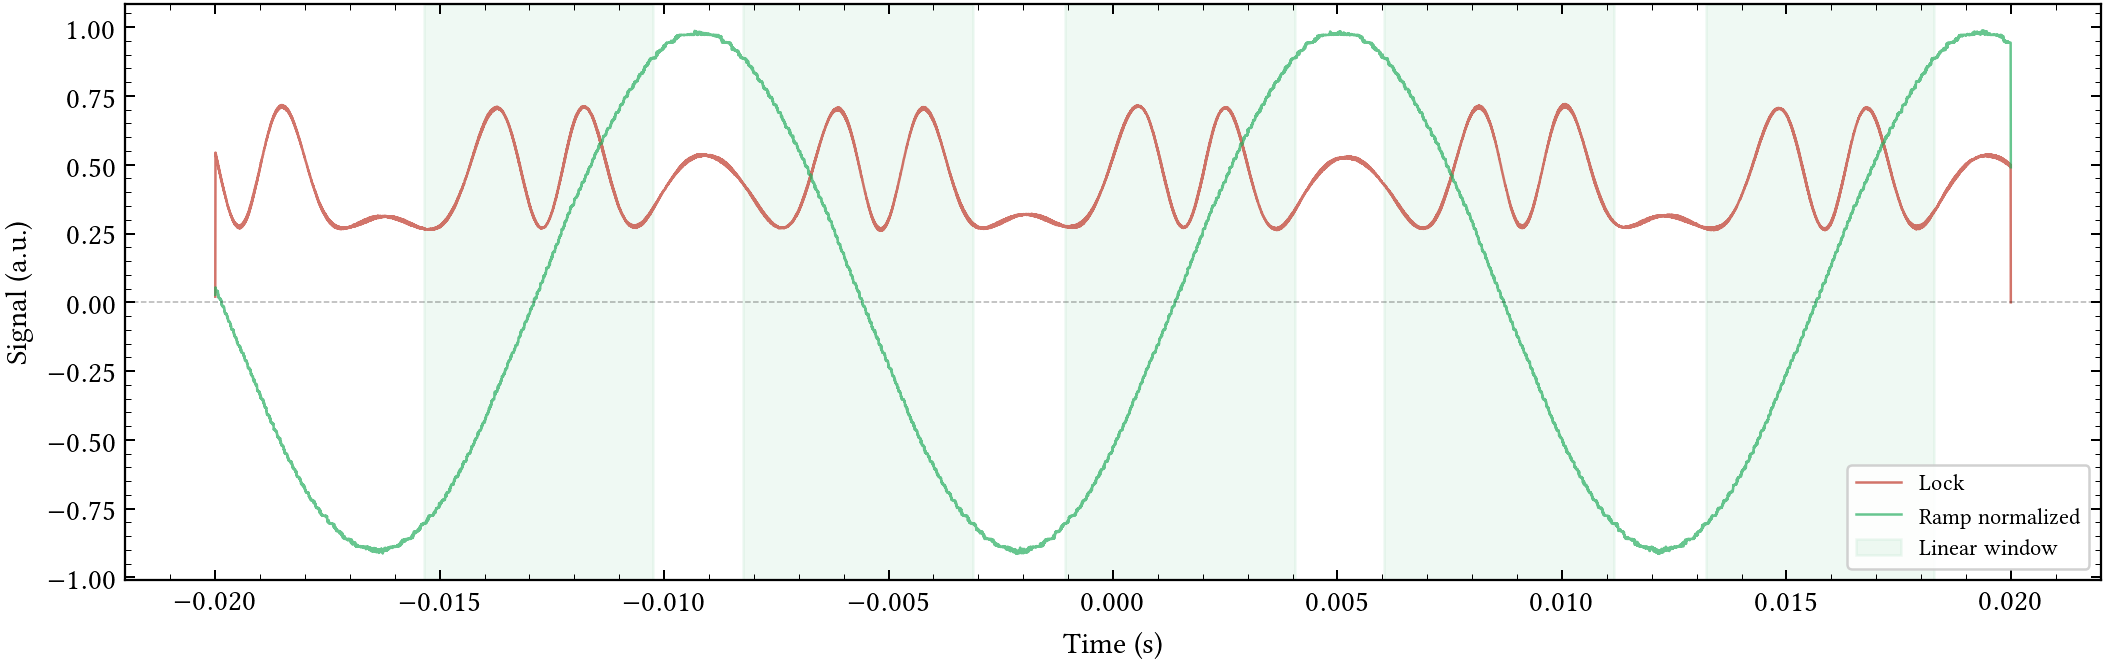

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))

# ax.plot(time, pump,        color="#C0392B", linewidth=1.2, label="Pump")
# ax.plot(time, shg,        color="#2E86AB", linewidth=1.2, label="SHG")
ax.plot(time, signal,        color="#C0392B", linewidth=1.0, alpha=0.7, label="Lock")
ax.plot(time, smooth_ramp, color="#27AE60", linewidth=1.0, alpha=0.7, label="Ramp normalized")

for i, (start_idx, end_idx) in enumerate(segments):
    ax.axvspan(time[start_idx], time[end_idx],
               color="#27AE60", alpha=0.07,
               label="Linear window" if i == 0 else None)

ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.3)
ax.tick_params(direction="in", top=True, right=True, length=4, width=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Signal (a.u.)")
ax.legend(frameon=True, framealpha=0.9, edgecolor="0.8", fontsize=9)
fig.tight_layout()

### Fabry Pérot Analysis

#### Settings

In [39]:
# Linear sweep window to analyse
WINDOW_NUMBER = 1

# Number of distinct peaks in one FSR
# In the example figure: m = 0, 1, ..., 5, therefore 6
PEAKS_PER_FSR = 2

# Peak detection settings
MIN_PEAK_PROMINENCE = 0.04
MIN_PEAK_DISTANCE = 100  # samples
DETECTION_SMOOTHING = 3  # Gaussian smoothing in samples

# Individual Lorentzian fitting window
LORENTZIAN_WINDOW_FRACTION = 0.42

#### Global Airy

In [43]:
def airy_function(x, offset, slope, amplitude, center, fsr, finesse):
    """
    Periodic Airy transmission.

    center   : position of one resonance
    fsr      : distance between consecutive resonances
    finesse : FSR / FWHM
    """
    airy_factor = 1.0 / np.sin(np.pi / (2.0 * finesse)) ** 2
    phase = np.pi * (x - center) / fsr

    baseline = offset + slope * (x - np.mean(x))
    transmission_peak = amplitude / (
            1.0 + airy_factor * np.sin(phase) ** 2
    )

    return baseline + transmission_peak

#### Select one linear sweep

In [40]:
start_idx, end_idx = segments[WINDOW_NUMBER]

# Keep the original acquisition order
x = ramp[start_idx:end_idx]
y = transmission[start_idx:end_idx]

# Reverse decreasing scans without sorting the points
if x[-1] < x[0]:
    x = x[::-1]
    y = y[::-1]

# Normalize transmission
y = y - np.percentile(y, 1)
y = y / np.percentile(y, 99)

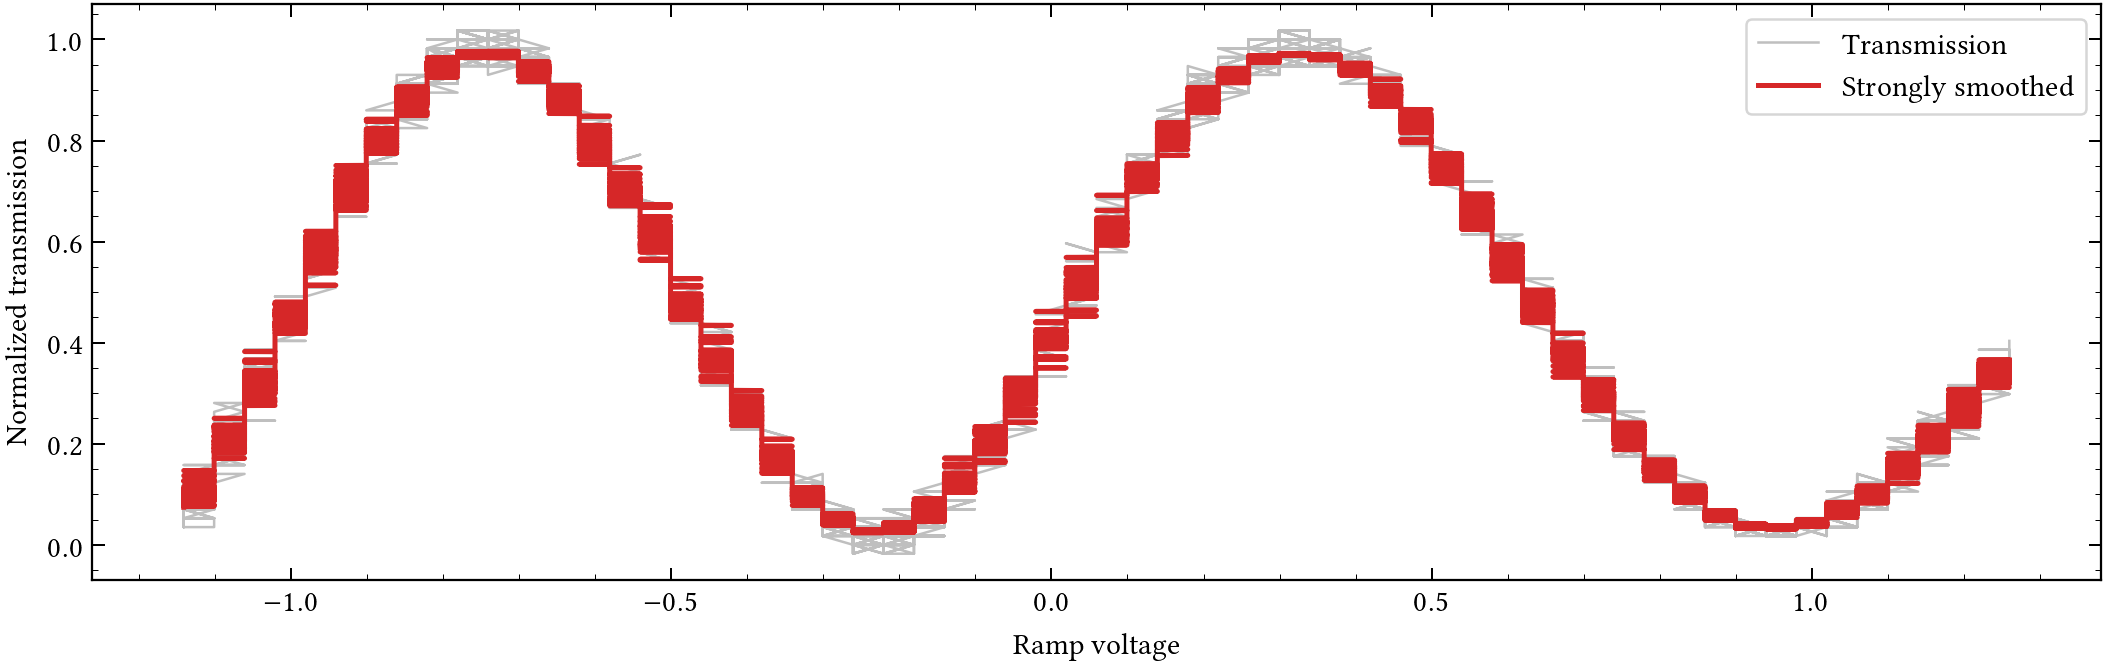

In [41]:
# Strong smoothing used only to identify the two broad resonances
smooth_points = max(20, len(y) // 100)
y_smooth = gaussian_filter1d(y, sigma=smooth_points)

plt.figure(figsize=(12, 4))
plt.plot(x, y, color="0.75", lw=1, label="Transmission")
plt.plot(x, y_smooth, color="tab:red", lw=2, label="Strongly smoothed")
plt.xlabel("Ramp voltage")
plt.ylabel("Normalized transmission")
plt.legend()
plt.tight_layout()
plt.show()

##### Detect the resonance peaks

In [42]:
peak_indices, properties = find_peaks(
    y_smooth,
    prominence=0.3,
    distance=len(y) // 3,
)

peak_x = x[peak_indices]

print(f"Detected cavity resonances: {len(peak_x)}")
print("Peak positions:", peak_x)

if len(peak_x) >= 2:
    fsr_guess = np.median(np.diff(peak_x))
    print(f"Estimated FSR: {fsr_guess:.4g} ramp volts")

Detected cavity resonances: 2
Peak positions: [-0.74070688  0.33929312]
Estimated FSR: 1.08 ramp volts


In [44]:
if len(peak_x) != 2:
    raise ValueError(
        "Exactly two cavity resonances must be detected. "
        "Adjust prominence or distance."
    )

fsr_guess = peak_x[1] - peak_x[0]
center_guess = peak_x[0]

offset_guess = np.percentile(y, 5)
amplitude_guess = np.percentile(y, 99) - offset_guess
finesse_guess = 2.0

initial_guess = [
    offset_guess,
    0.0,
    amplitude_guess,
    center_guess,
    fsr_guess,
    finesse_guess,
]

x_range = np.ptp(x)

lower_bounds = [
    -0.5,  # offset
    -2.0 / x_range,  # slope
    0.0,  # amplitude
    center_guess - 0.2 * fsr_guess,
    0.7 * fsr_guess,
    1.01,  # finesse
]

upper_bounds = [
    1.5,
    2.0 / x_range,
    2.0,
    center_guess + 0.2 * fsr_guess,
    1.3 * fsr_guess,
    20.0,
]

In [45]:
airy_parameters, airy_covariance = curve_fit(
    airy_function,
    x,
    y,
    p0=initial_guess,
    bounds=(lower_bounds, upper_bounds),
    maxfev=50_000,
)

airy_errors = np.sqrt(np.diag(airy_covariance))

(
    offset_fit,
    slope_fit,
    amplitude_fit,
    center_fit,
    fsr_fit,
    finesse_airy,
) = airy_parameters

finesse_airy_error = airy_errors[5]
airy_fwhm = fsr_fit / finesse_airy

print(f"FSR              = {fsr_fit:.5g} V")
print(f"Airy FWHM        = {airy_fwhm:.5g} V")
print(
    f"Airy finesse     = "
    f"{finesse_airy:.3f} ± {finesse_airy_error:.3f}"
)

FSR              = 1.1186 V
Airy FWHM        = 0.67408 V
Airy finesse     = 1.659 ± 0.021


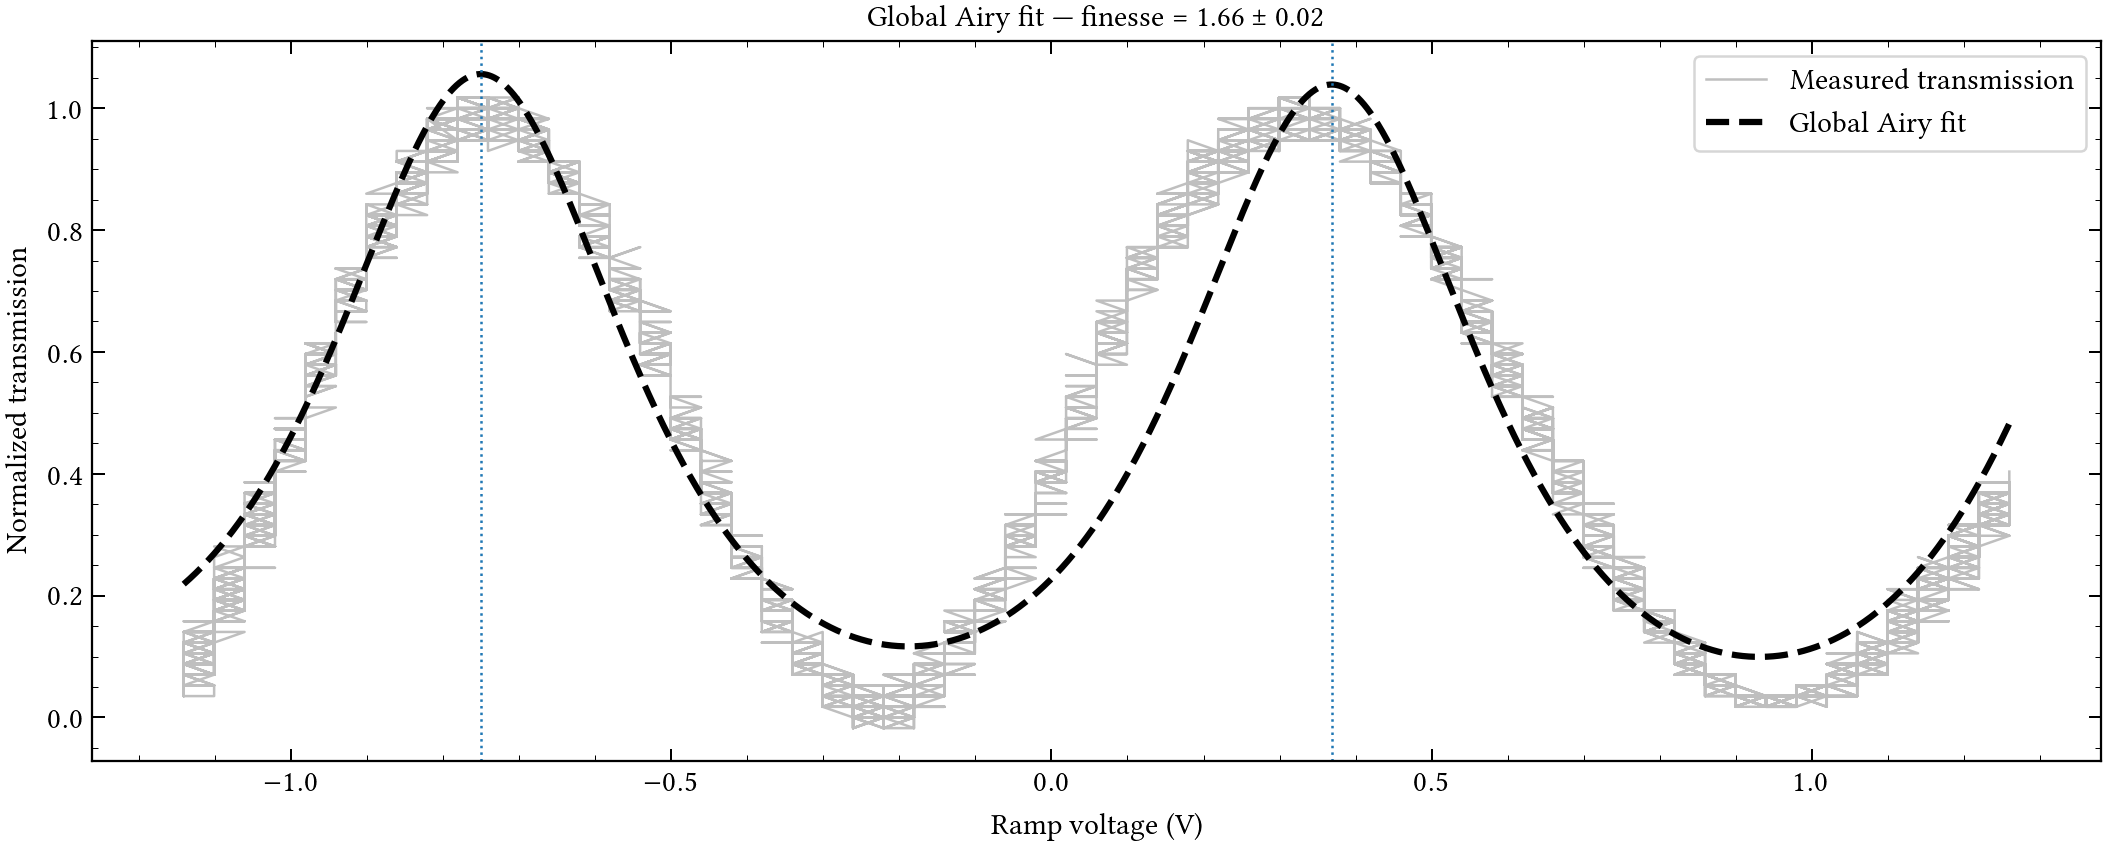

In [46]:
x_fit = np.linspace(x.min(), x.max(), 3000)

y_airy_fit = airy_function(
    x_fit,
    *airy_parameters,
)

plt.figure(figsize=(12, 5))

plt.plot(
    x,
    y,
    color="0.75",
    linewidth=1,
    label="Measured transmission",
)

plt.plot(
    x_fit,
    y_airy_fit,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label="Global Airy fit",
)

for resonance_number in range(-3, 4):
    resonance_position = center_fit + resonance_number * fsr_fit

    if x.min() <= resonance_position <= x.max():
        plt.axvline(
            resonance_position,
            color="tab:blue",
            linestyle=":",
            linewidth=1,
        )

plt.xlabel("Ramp voltage (V)")
plt.ylabel("Normalized transmission")
plt.title(
    f"Global Airy fit — finesse = "
    f"{finesse_airy:.2f} ± {finesse_airy_error:.2f}"
)
plt.legend()
plt.tight_layout()
plt.show()

#### Airy on all windows

In [60]:
def airy_mode(
        x,
        center,
        fsr,
        finesse,
        amplitude,
):
    """
    One periodic Airy mode family.
    """
    airy_factor = (
            1.0
            / np.sin(np.pi / (2.0 * finesse)) ** 2
    )

    phase = np.pi * (x - center) / fsr

    return amplitude / (
            1.0
            + airy_factor * np.sin(phase) ** 2
    )


def total_airy_model(
        x,
        offset,
        slope,
        fsr,
        finesse,
        center_1,
        center_2,
        amplitude_1,
        amplitude_2,
        x_reference,
):
    """
    Linear baseline plus two periodic Airy mode families.
    """
    baseline = (
            offset
            + slope * (x - x_reference)
    )

    mode_1 = airy_mode(
        x,
        center_1,
        fsr,
        finesse,
        amplitude_1,
    )

    mode_2 = airy_mode(
        x,
        center_2,
        fsr,
        finesse,
        amplitude_2,
    )

    return baseline + mode_1 + mode_2

In [61]:
PEAKS_PER_FSR = 2

# Peak detection
PEAK_PROMINENCE = 0.30
PEAK_DISTANCE_FRACTION = 1 / 3

# Initial finesse
FINESSE_GUESS = 2.0
FINESSE_MIN = 1.01
FINESSE_MAX = 20.0

In [62]:
all_window_fits = []

for window_number, (start_idx, end_idx) in enumerate(segments):

    # --------------------------------------------------
    # Extract one sweep
    # --------------------------------------------------

    x = ramp[start_idx:end_idx].copy()
    y = transmission[start_idx:end_idx].copy()

    if len(x) < 10:
        print(
            f"Window {window_number}: skipped — "
            "not enough points"
        )
        continue

    # Put decreasing scans in increasing-voltage order
    if x[-1] < x[0]:
        x = x[::-1]
        y = y[::-1]

    x_range = np.ptp(x)

    if x_range <= 0:
        print(
            f"Window {window_number}: skipped — "
            "zero ramp range"
        )
        continue

    # This reference is used only to centre the baseline
    x_reference = np.mean(x)

    # --------------------------------------------------
    # Prepare a normalized copy for peak detection only
    # --------------------------------------------------

    y_low_detection = np.percentile(y, 5)
    y_high_detection = np.percentile(y, 99)

    y_range_detection = (
            y_high_detection - y_low_detection
    )

    if y_range_detection <= 0:
        print(
            f"Window {window_number}: skipped — "
            "no usable transmission range"
        )
        continue

    y_detection = (
            (y - y_low_detection)
            / y_range_detection
    )

    # Strong smoothing is used only for detection
    smooth_points = max(
        20,
        len(y_detection) // 100,
    )

    y_smooth = gaussian_filter1d(
        y_detection,
        sigma=smooth_points,
    )

    minimum_peak_distance = max(
        1,
        int(len(y) * PEAK_DISTANCE_FRACTION),
    )

    peak_indices, peak_properties = find_peaks(
        y_smooth,
        prominence=PEAK_PROMINENCE,
        distance=minimum_peak_distance,
    )

    peak_x = x[peak_indices]

    print(
        f"Window {window_number}: "
        f"{len(peak_x)} peaks detected"
    )

    if len(peak_x) != 2:
        print(
            f"Window {window_number}: skipped — "
            "exactly two neighbouring peaks are required"
        )
        continue

    # Ensure increasing peak order
    peak_x = np.sort(peak_x)

    # --------------------------------------------------
    # Initial parameter estimates
    # --------------------------------------------------

    peak_spacing = peak_x[1] - peak_x[0]

    if peak_spacing <= 0:
        print(
            f"Window {window_number}: skipped — "
            "invalid peak spacing"
        )
        continue

    # Two interleaved peaks per complete FSR
    fsr_guess = (
            PEAKS_PER_FSR * peak_spacing
    )

    # Guesses from the original, non-normalized signal
    y_low = np.percentile(y, 5)
    y_high = np.percentile(y, 99)
    y_range = y_high - y_low

    if y_range <= 0:
        print(
            f"Window {window_number}: skipped — "
            "invalid signal amplitude"
        )
        continue

    offset_guess = y_low
    slope_guess = 0.0
    amplitude_guess = y_range

    initial_parameters = [
        offset_guess,
        slope_guess,
        fsr_guess,
        FINESSE_GUESS,
        peak_x[0],
        peak_x[1],
        amplitude_guess,
        amplitude_guess,
    ]

    # --------------------------------------------------
    # Parameter bounds
    # --------------------------------------------------

    lower_bounds = [
        y.min() - y_range,
        -2.0 * y_range / x_range,
        0.7 * fsr_guess,
        FINESSE_MIN,
        peak_x[0] - 0.2 * peak_spacing,
        peak_x[1] - 0.2 * peak_spacing,
        0.0,
        0.0,
    ]

    upper_bounds = [
        y.max() + y_range,
        2.0 * y_range / x_range,
        1.3 * fsr_guess,
        FINESSE_MAX,
        peak_x[0] + 0.2 * peak_spacing,
        peak_x[1] + 0.2 * peak_spacing,
        2.0 * y_range,
        2.0 * y_range,
    ]


    # curve_fit expects a function whose only independent
    # argument is x. The fixed x_reference is added here.
    def model_for_this_window(
            x_values,
            offset,
            slope,
            fsr,
            finesse,
            center_1,
            center_2,
            amplitude_1,
            amplitude_2,
    ):
        return total_airy_model(
            x_values,
            offset,
            slope,
            fsr,
            finesse,
            center_1,
            center_2,
            amplitude_1,
            amplitude_2,
            x_reference,
        )


    # --------------------------------------------------
    # Fit the original transmission
    # --------------------------------------------------

    try:
        parameters, covariance = curve_fit(
            model_for_this_window,
            x,
            y,
            p0=initial_parameters,
            bounds=(lower_bounds, upper_bounds),
            maxfev=100_000,
        )

    except (RuntimeError, ValueError) as error:
        print(
            f"Window {window_number}: "
            f"fit failed — {error}"
        )
        continue

    errors = np.sqrt(
        np.diag(covariance)
    )

    (
        offset_fit,
        slope_fit,
        fsr_fit,
        finesse_fit,
        center_1_fit,
        center_2_fit,
        amplitude_1_fit,
        amplitude_2_fit,
    ) = parameters

    (
        offset_error,
        slope_error,
        fsr_error,
        finesse_error,
        center_1_error,
        center_2_error,
        amplitude_1_error,
        amplitude_2_error,
    ) = errors

    fwhm_fit = fsr_fit / finesse_fit

    fwhm_error = fwhm_fit * np.sqrt(
        (fsr_error / fsr_fit) ** 2
        + (finesse_error / finesse_fit) ** 2
    )

    mode_separation = (
            center_2_fit - center_1_fit
    )

    relative_mode_separation = (
            mode_separation / fsr_fit
    )

    # --------------------------------------------------
    # Store the result
    # --------------------------------------------------

    all_window_fits.append({
        "window": window_number,
        "x": x,
        "y": y,
        "y_smooth": y_smooth,
        "peak_indices": peak_indices,
        "peak_x": peak_x,
        "x_reference": x_reference,
        "parameters": parameters,
        "errors": errors,
        "offset": offset_fit,
        "offset_error": offset_error,
        "slope": slope_fit,
        "slope_error": slope_error,
        "fsr": fsr_fit,
        "fsr_error": fsr_error,
        "fwhm": fwhm_fit,
        "fwhm_error": fwhm_error,
        "finesse": finesse_fit,
        "finesse_error": finesse_error,
        "center_1": center_1_fit,
        "center_2": center_2_fit,
        "amplitude_1": amplitude_1_fit,
        "amplitude_2": amplitude_2_fit,
        "mode_separation": mode_separation,
        "relative_mode_separation": relative_mode_separation,
    })

    print(
        f"  FSR      = {fsr_fit:.5g} "
        f"± {fsr_error:.2g} V"
    )
    print(
        f"  FWHM     = {fwhm_fit:.5g} "
        f"± {fwhm_error:.2g} V"
    )
    print(
        f"  Finesse  = {finesse_fit:.3f} "
        f"± {finesse_error:.3f}"
    )
    print(
        f"  Mode separation / FSR = "
        f"{relative_mode_separation:.3f}"
    )

Window 0: 2 peaks detected
  FSR      = 2.3409 ± 0.004 V
  FWHM     = 0.74636 ± 0.0069 V
  Finesse  = 3.136 ± 0.028
  Mode separation / FSR = 0.480
Window 1: 2 peaks detected
  FSR      = 2.3991 ± 0.0024 V
  FWHM     = 0.73125 ± 0.0037 V
  Finesse  = 3.281 ± 0.016
  Mode separation / FSR = 0.456
Window 2: 2 peaks detected
  FSR      = 2.3396 ± 0.004 V
  FWHM     = 0.74788 ± 0.007 V
  Finesse  = 3.128 ± 0.029
  Mode separation / FSR = 0.480
Window 3: 2 peaks detected
  FSR      = 2.4073 ± 0.0025 V
  FWHM     = 0.73504 ± 0.0037 V
  Finesse  = 3.275 ± 0.016
  Mode separation / FSR = 0.454
Window 4: 2 peaks detected
  FSR      = 2.3474 ± 0.004 V
  FWHM     = 0.74733 ± 0.0068 V
  Finesse  = 3.141 ± 0.028
  Mode separation / FSR = 0.480


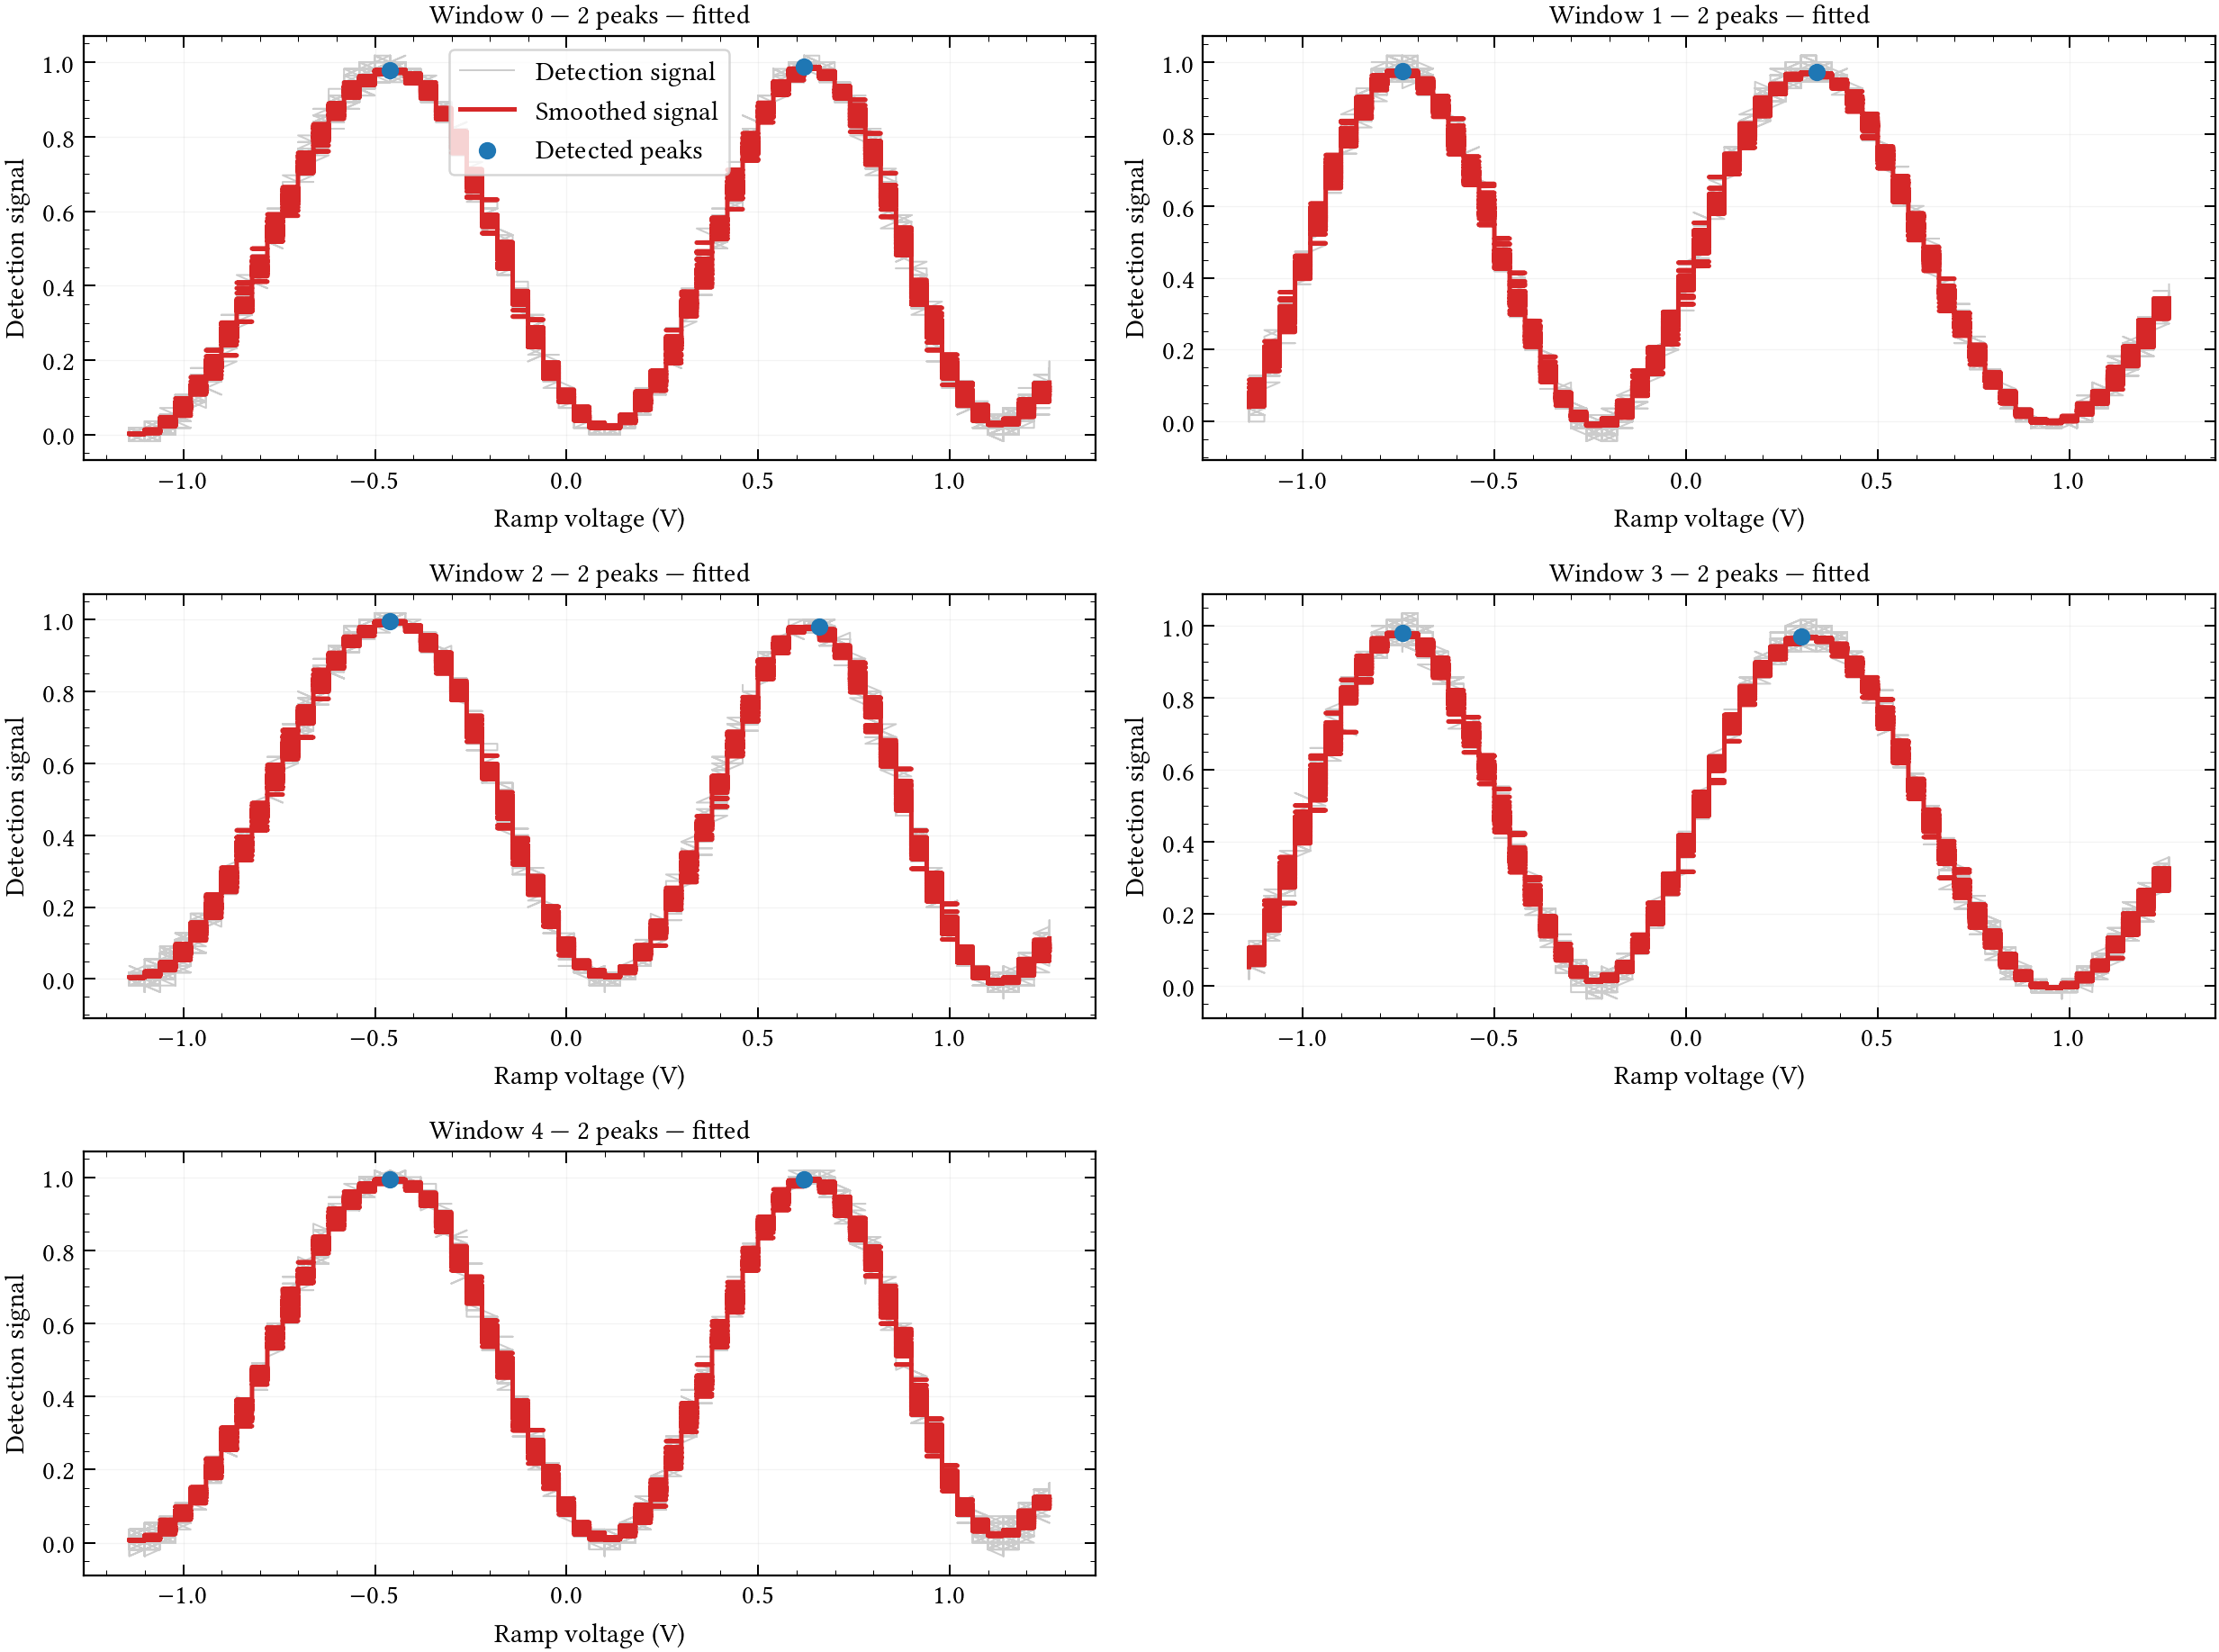

In [63]:
number_of_windows = len(segments)

cols = 2
rows = int(np.ceil(number_of_windows / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(7 * cols, 3.5 * rows),
    squeeze=False,
)

axes = axes.ravel()

fit_by_window = {
    fit["window"]: fit
    for fit in all_window_fits
}

for window_number, (start_idx, end_idx) in enumerate(segments):

    ax = axes[window_number]

    x_window = ramp[start_idx:end_idx].copy()
    y_window = transmission[start_idx:end_idx].copy()

    if x_window[-1] < x_window[0]:
        x_window = x_window[::-1]
        y_window = y_window[::-1]

    y_low = np.percentile(y_window, 5)
    y_high = np.percentile(y_window, 99)
    y_range = y_high - y_low

    if y_range <= 0:
        ax.set_title(
            f"Window {window_number}: invalid signal"
        )
        continue

    y_detection = (
            (y_window - y_low) / y_range
    )

    smooth_points = max(
        20,
        len(y_detection) // 100,
    )

    y_smooth = gaussian_filter1d(
        y_detection,
        sigma=smooth_points,
    )

    peak_indices, _ = find_peaks(
        y_smooth,
        prominence=PEAK_PROMINENCE,
        distance=max(
            1,
            int(
                len(y_window)
                * PEAK_DISTANCE_FRACTION
            ),
        ),
    )

    ax.plot(
        x_window,
        y_detection,
        color="0.80",
        linewidth=0.8,
        label="Detection signal",
    )

    ax.plot(
        x_window,
        y_smooth,
        color="tab:red",
        linewidth=2,
        label="Smoothed signal",
    )

    ax.scatter(
        x_window[peak_indices],
        y_smooth[peak_indices],
        color="tab:blue",
        s=45,
        zorder=3,
        label="Detected peaks",
    )

    fitted = window_number in fit_by_window

    ax.set_title(
        f"Window {window_number} — "
        f"{len(peak_indices)} peaks"
        + (" — fitted" if fitted else " — skipped")
    )

    ax.set_xlabel("Ramp voltage (V)")
    ax.set_ylabel("Detection signal")
    ax.grid(alpha=0.15)

    if window_number == 0:
        ax.legend()

# Hide unused axes
for ax in axes[number_of_windows:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

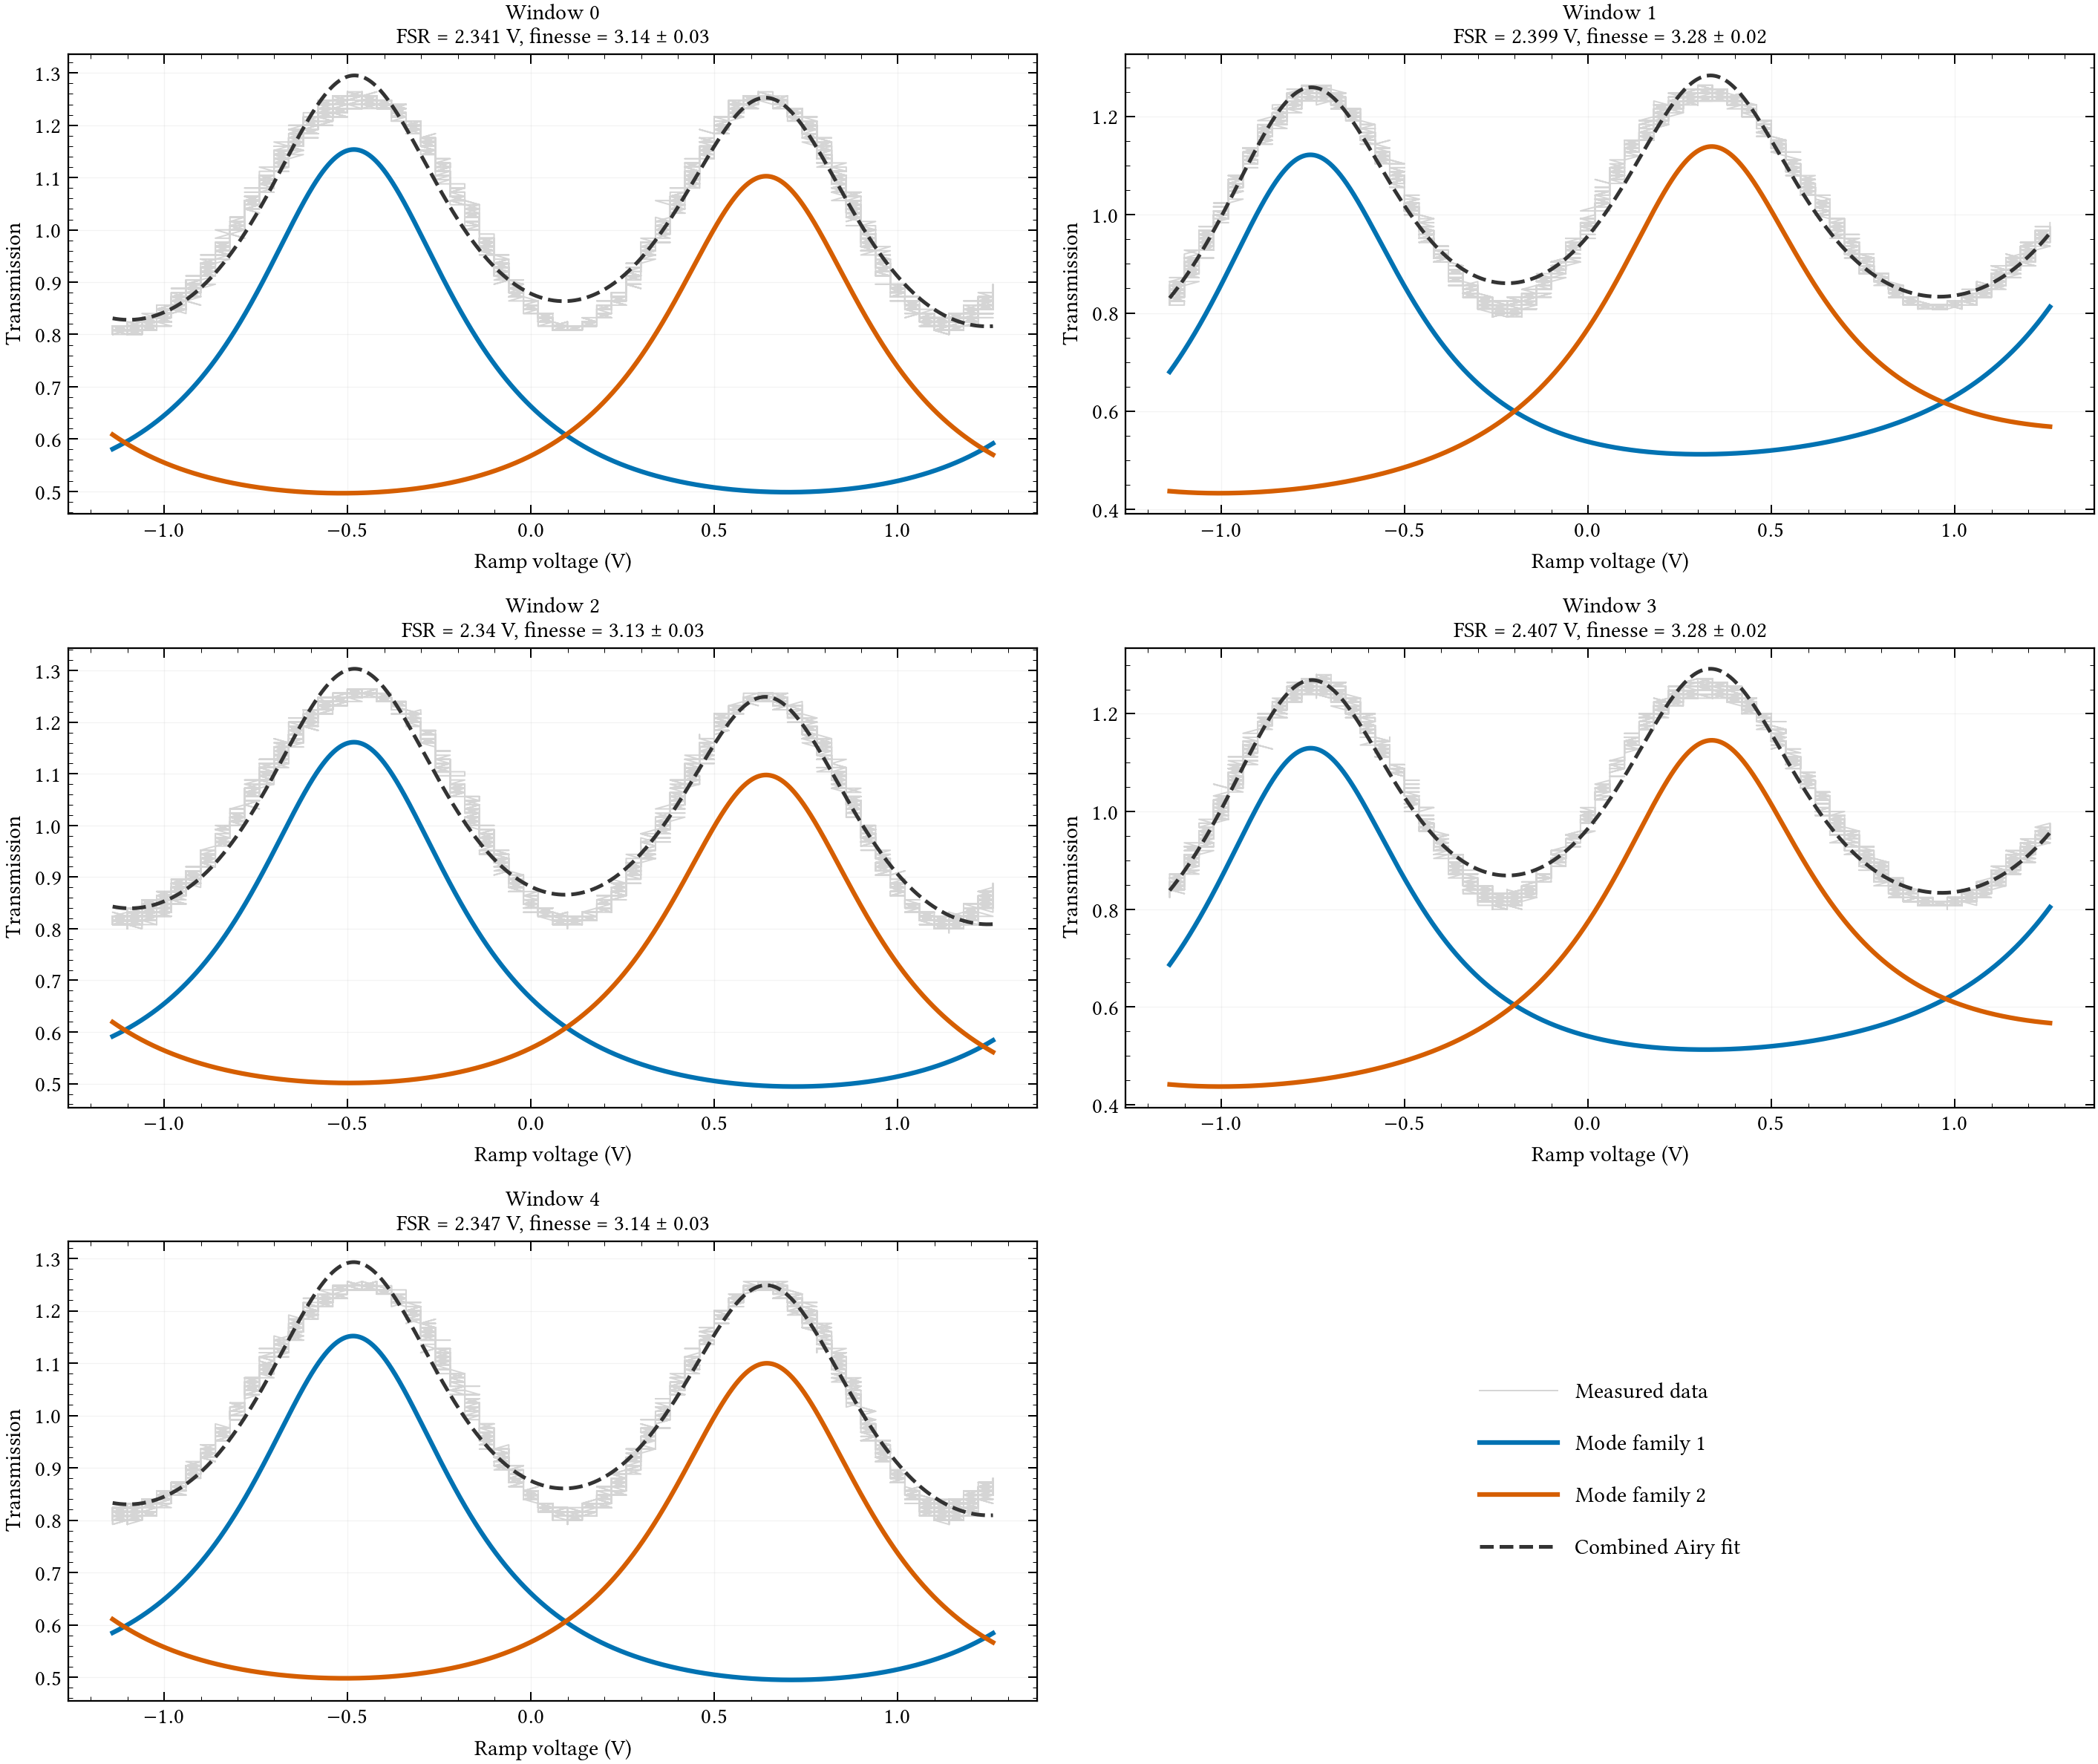

In [73]:
if not all_window_fits:
    raise ValueError("No window was fitted successfully.")

MODE_1_COLOR = "#0072B2"  # deep blue
MODE_2_COLOR = "#D55E00"  # vermilion orange

number_of_fits = len(all_window_fits)
cols = 2
rows = int(np.ceil(number_of_fits / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(8 * cols, 4.5 * rows),
    squeeze=False,
)

axes = axes.ravel()

for ax, fit in zip(axes, all_window_fits):
    x = fit["x"]
    y = fit["y"]

    x_fit = np.linspace(
        x.min(),
        x.max(),
        5000,
    )

    baseline_fit = (
            fit["offset"]
            + fit["slope"]
            * (x_fit - fit["x_reference"])
    )

    mode_1_fit = airy_mode(
        x_fit,
        fit["center_1"],
        fit["fsr"],
        fit["finesse"],
        fit["amplitude_1"],
    )

    mode_2_fit = airy_mode(
        x_fit,
        fit["center_2"],
        fit["fsr"],
        fit["finesse"],
        fit["amplitude_2"],
    )

    total_fit = (
            baseline_fit
            + mode_1_fit
            + mode_2_fit
    )

    # Original measured transmission
    ax.plot(
        x,
        y,
        color="0.75",
        linewidth=0.8,
        alpha=0.65,
        label="Measured transmission",
    )

    # Individual periodic Airy families
    ax.plot(
        x_fit,
        baseline_fit + mode_1_fit,
        color=MODE_1_COLOR,
        linewidth=2.5,
        label="Mode family 1",
    )

    ax.plot(
        x_fit,
        baseline_fit + mode_2_fit,
        color=MODE_2_COLOR,
        linewidth=2.5,
        label="Mode family 2",
    )

    # Sum fitted to the measured signal
    ax.plot(
        x_fit,
        total_fit,
        color="0.20",
        linestyle="--",
        linewidth=2,
        label="Total Airy fit",
    )

    ax.set_title(
        f"Window {fit['window']}\n"
        f"FSR = {fit['fsr']:.4g} V, "
        f"finesse = {fit['finesse']:.2f} "
        f"± {fit['finesse_error']:.2f}"
    )

    ax.set_xlabel("Ramp voltage (V)")
    ax.set_ylabel("Transmission")
    ax.grid(alpha=0.15)

# Use the first unused subplot as a legend panel
handles, labels = axes[0].get_legend_handles_labels()

if number_of_fits < len(axes):
    legend_ax = axes[number_of_fits]
    legend_ax.axis("off")

    legend_ax.legend(
        handles,
        [
            "Measured data",
            "Mode family 1",
            "Mode family 2",
            "Combined Airy fit",
        ],
        loc="center",
        frameon=False,
        fontsize=12,
        handlelength=3.5,
        labelspacing=1.4,
    )

    # Hide any remaining unused subplots
    for ax in axes[number_of_fits + 1:]:
        ax.set_visible(False)

else:
    # Fallback when every subplot is occupied
    fig.legend(
        handles,
        [
            "Measured data",
            "Mode family 1",
            "Mode family 2",
            "Combined Airy fit",
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=4,
        frameon=True,
        handlelength=3,
    )

# No overall figure title
plt.tight_layout()

if number_of_fits == len(axes):
    fig.subplots_adjust(bottom=0.10)

plt.show()

In [66]:
finesses = np.array([
    fit["finesse"]
    for fit in all_window_fits
])

fsr_values = np.array([
    fit["fsr"]
    for fit in all_window_fits
])

fwhm_values = np.array([
    fit["fwhm"]
    for fit in all_window_fits
])

print(
    f"Successfully fitted windows: "
    f"{len(all_window_fits)} / {len(segments)}"
)

if len(all_window_fits) > 1:

    print(
        f"Mean FSR      = "
        f"{np.mean(fsr_values):.5g} "
        f"± {np.std(fsr_values, ddof=1):.2g} V"
    )

    print(
        f"Mean FWHM     = "
        f"{np.mean(fwhm_values):.5g} "
        f"± {np.std(fwhm_values, ddof=1):.2g} V"
    )

    print(
        f"Mean finesse  = "
        f"{np.mean(finesses):.3f} "
        f"± {np.std(finesses, ddof=1):.3f}"
    )

elif len(all_window_fits) == 1:

    print(
        f"Finesse = {finesses[0]:.3f}"
    )

Successfully fitted windows: 5 / 5
Mean FSR      = 2.3669 ± 0.033 V
Mean FWHM     = 0.74157 ± 0.0078 V
Mean finesse  = 3.192 ± 0.078


### Lorentzian

In [64]:
peak_fits = []
all_peaks = []

height = 0.25  # minimum height of peaks, adjust as needed

N = 550  # number of points to take around each peak for fitting, adjust as needed

# first pass: find all peaks
for window_id, (start_idx, end_idx) in enumerate(segments):

    segment_signal = signal[start_idx:end_idx]
    # print(segment_signal.max())
    # print(segment_signal.min())
    peaks, props = find_peaks(
        segment_signal,
        height=height,
        prominence=0.08,
        distance=100  # Minimum distance between peaks
    )

    print(f"Window {window_id}: {len(peaks)} peaks")
    print(np.allclose(segment_signal[peaks],
                  props["peak_heights"]))

    print(segment_signal[peaks])
    print(props["peak_heights"])

    for peak in peaks:
        all_peaks.append((start_idx + peak, window_id))



print(f"Total peaks found: {len(all_peaks)}")

# calibration from all detected peaks
peak_times = np.array([time[idx] for idx, window_id in all_peaks])
peak_times = np.sort(peak_times)

time_per_FSR = np.median(np.diff(peak_times))
Hz_per_sec = FSR / time_per_FSR

print(f"time_per_FSR = {time_per_FSR:.3e} s")
print(f"Hz_per_sec   = {Hz_per_sec:.3e} Hz/s")

# second pass: fit all peaks
for idx, window_id in all_peaks:

    if idx - N < 0 or idx + N >= len(signal):
        continue

    xdata = time[idx-N:idx+N]
    ydata = signal[idx-N:idx+N]

    A_guess = np.max(ydata) - np.min(ydata)
    x0_guess = time[idx]
    gamma_guess = 20 * (time[1] - time[0])
    C_guess = np.min(ydata)

    p0 = [A_guess, x0_guess, gamma_guess, C_guess]


    popt, pcov = curve_fit(
        lorentzian,
        xdata,
        ydata,
        p0=p0,
        maxfev=20000
    )

    A_fit, x0_fit, gamma_fit, C_fit = popt

    gamma_freq = abs(gamma_fit * Hz_per_sec)
    finesse = FSR / gamma_freq

    peak_fits.append({
        "A": A_fit,
        "x0": x0_fit,
        "gamma_time": gamma_fit,
        "gamma_freq": gamma_freq,
        "finesse": finesse,
        "C": C_fit,
        "window_id": window_id,
        "time_per_FSR": time_per_FSR
    })

    # print(window_id,
    #   idx,
    #   signal[idx],
    #   np.max(signal[idx-N:idx+N]))

print(f"Fitted {len(peak_fits)} peaks")


Window 0: 1 peaks
True
[0.37504]
[0.37504]
Window 1: 0 peaks
True
[]
[]
Window 2: 2 peaks
True
[0.28608 0.28608]
[0.28608 0.28608]
Window 3: 0 peaks
True
[]
[]
Window 4: 1 peaks
True
[0.37792]
[0.37792]
Window 5: 0 peaks
True
[]
[]
Window 6: 0 peaks
True
[]
[]
Window 7: 2 peaks
True
[0.37792 0.37792]
[0.37792 0.37792]
Window 8: 0 peaks
True
[]
[]
Window 9: 0 peaks
True
[]
[]
Window 10: 1 peaks
True
[0.37792]
[0.37792]
Window 11: 2 peaks
True
[0.37792 0.37792]
[0.37792 0.37792]
Window 12: 0 peaks
True
[]
[]
Window 13: 0 peaks
True
[]
[]
Window 14: 1 peaks
True
[0.37792]
[0.37792]
Total peaks found: 10
time_per_FSR = 1.511e-02 s
Hz_per_sec   = 2.918e+10 Hz/s
Fitted 8 peaks


#### Plot fitted curves

Fitted 8 peaks across 15 windows.


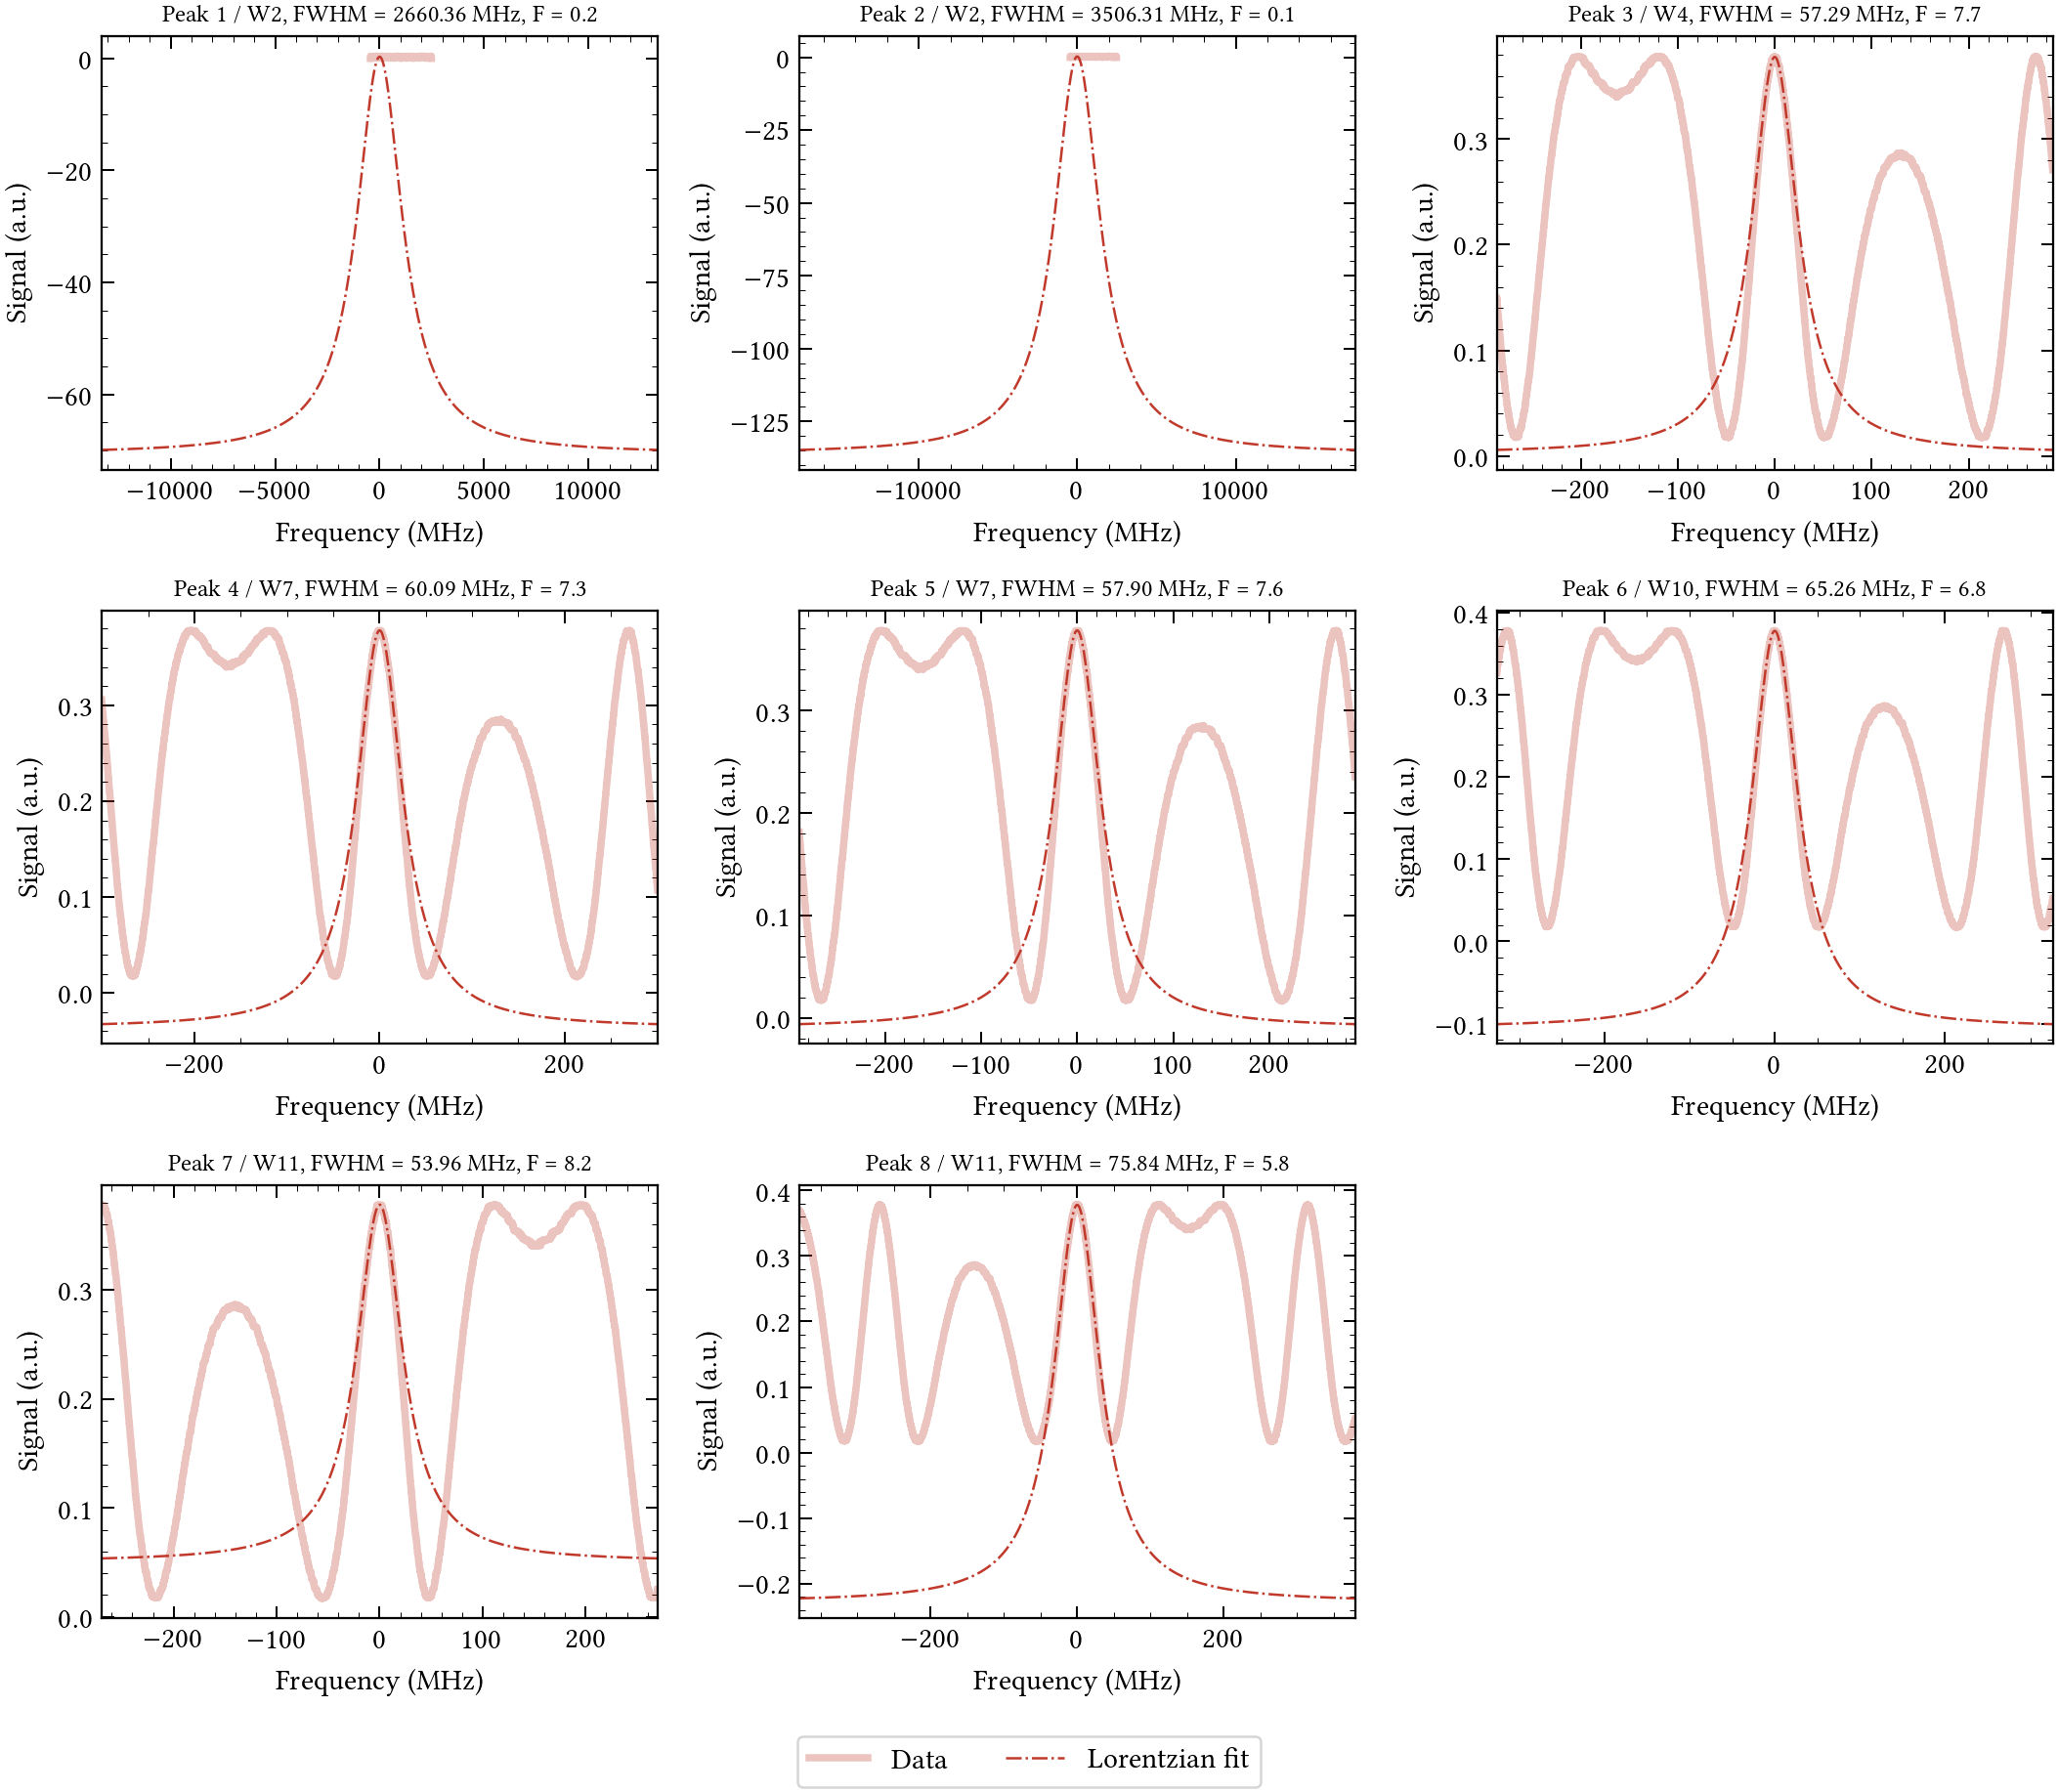

In [65]:
num_peaks = len(peak_fits)
print(f"Fitted {num_peaks} peaks across {len(segments)} windows.")

cols = int(np.ceil(np.sqrt(num_peaks)))
rows = int(np.ceil(num_peaks / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4*cols, 3.5*rows)
)

axes = np.array(axes).reshape(-1)

for i, pf in enumerate(peak_fits):

    ax = axes[i]

    A = pf["A"]
    x0 = pf["x0"]
    gamma_time = pf["gamma_time"]
    gamma_freq = pf["gamma_freq"]
    finesse = pf["finesse"]
    C = pf["C"]

    time_per_FSR = pf["time_per_FSR"]
    Hz_per_sec = FSR / time_per_FSR

    t_fit = np.linspace(
        x0 - 5*abs(gamma_time),
        x0 + 5*abs(gamma_time),
        1000
    )

    y_fit = lorentzian(t_fit, A, x0, gamma_time, C)

    freq_fit = (t_fit - x0) * Hz_per_sec / 1e6
    mask = (time >= t_fit[0]) & (time <= t_fit[-1])

    freq_data = (time[mask] - x0) * Hz_per_sec / 1e6

    ax.plot(
        freq_data,
        signal[mask],
        color="#C0392B",
        alpha=0.3,
        lw=3.0,
        label="Data"
    )
    ax.plot(freq_fit, y_fit, color="#C0392B", linestyle="-.", lw=1.0, label="Lorentzian fit")

    ax.set_xlim(freq_fit[0], freq_fit[-1])

    ax.set_title(
        f"Peak {i+1} / W{pf['window_id']}, "
        f"FWHM = {gamma_freq/1e6:.2f} MHz, "
        f"F = {finesse:.1f}",
        fontsize=10
    )

    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Signal (a.u.)")

# hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis("off")

# common legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

#### Summary

In [56]:
for i, pf in enumerate(peak_fits):
    print(
        f"Peak {i+1}: "
        f"FWHM = {pf['gamma_freq']/1e6:.3f} MHz, "
        f"Finesse = {pf['finesse']:.1f}"
    )

# Average FWHM and Finesse
gamma_freqs = np.array([pf["gamma_freq"] for pf in peak_fits])
finesses = np.array([pf["finesse"] for pf in peak_fits])
print(f"Average FWHM = {np.mean(gamma_freqs)/1e6:.3f} MHz")
print(f"Average Finesse = {np.mean(finesses):.1f}")

Peak 1: FWHM = 3.520 MHz, Finesse = 170.3
Peak 2: FWHM = 3.420 MHz, Finesse = 175.3
Peak 3: FWHM = 3.462 MHz, Finesse = 173.2
Peak 4: FWHM = 3.432 MHz, Finesse = 174.7
Peak 5: FWHM = 3.408 MHz, Finesse = 175.9
Peak 6: FWHM = 3.356 MHz, Finesse = 178.6
Peak 7: FWHM = 3.372 MHz, Finesse = 177.8
Peak 8: FWHM = 3.358 MHz, Finesse = 178.6
Peak 9: FWHM = 3.386 MHz, Finesse = 177.1
Peak 10: FWHM = 3.291 MHz, Finesse = 182.2
Average FWHM = 3.401 MHz
Average Finesse = 176.4


### Double Lorentzian

In [17]:
def lorentzian(x, A, x0, gamma):
    return A * (0.5 * gamma)**2 / (
        (x - x0)**2 + (0.5 * gamma)**2
    )

def double_lorentzian(x, A1, x01, gamma1, A2, x02, gamma2, C):
    return (
        lorentzian(x, A1, x01, gamma1)
        + lorentzian(x, A2, x02, gamma2)
        + C
    )

In [27]:
time_per_FSR = np.median(np.diff([
    time[start_idx]
    for start_idx, end_idx in segments
]))

Hz_per_sec = FSR / time_per_FSR

double_peak_fits = []

dt = np.median(np.diff(time))

for window_id, (start_idx, end_idx) in enumerate(segments):

    xdata = time[start_idx:end_idx]
    ydata = signal[start_idx:end_idx]

    # Find candidate peaks inside this window
    peaks, properties = find_peaks(
        ydata,
        prominence=0.05,
        distance=100
    )

    if len(peaks) < 2:
        print(f"Window {window_id}: fewer than two peaks")
        continue

    # Keep the two most prominent peaks
    order = np.argsort(properties["prominences"])[-2:]
    selected_peaks = np.sort(peaks[order])

    peak1, peak2 = selected_peaks

    # Initial baseline
    C_guess = np.min(ydata)

    # Initial amplitudes
    A1_guess = ydata[peak1] - C_guess
    A2_guess = ydata[peak2] - C_guess

    # Initial centres
    x01_guess = xdata[peak1]
    x02_guess = xdata[peak2]

    # Initial linewidths
    gamma1_guess = 50 * dt
    gamma2_guess = 50 * dt

    p0 = [
        A1_guess,
        x01_guess,
        gamma1_guess,
        A2_guess,
        x02_guess,
        gamma2_guess,
        C_guess
    ]

    lower_bounds = [
        0,
        xdata[0],
        dt,
        0,
        xdata[0],
        dt,
        0
    ]

    upper_bounds = [
        2 * np.max(ydata),
        xdata[-1],
        xdata[-1] - xdata[0],
        2 * np.max(ydata),
        xdata[-1],
        xdata[-1] - xdata[0],
        np.max(ydata)
    ]

    try:
        popt, pcov = curve_fit(
            double_lorentzian,
            xdata,
            ydata,
            p0=p0,
            bounds=(lower_bounds, upper_bounds),
            maxfev=50000
        )

    except RuntimeError:
        print(f"Window {window_id}: fit failed")
        continue

    (
        A1_fit,
        x01_fit,
        gamma1_time,
        A2_fit,
        x02_fit,
        gamma2_time,
        C_fit
    ) = popt

    gamma1_freq = abs(gamma1_time) * Hz_per_sec
    gamma2_freq = abs(gamma2_time) * Hz_per_sec

    finesse1 = FSR / gamma1_freq
    finesse2 = FSR / gamma2_freq

    double_peak_fits.append({
        "window_id": window_id,

        "A1": A1_fit,
        "x01": x01_fit,
        "gamma1_time": abs(gamma1_time),
        "gamma1_freq": gamma1_freq,
        "finesse1": finesse1,

        "A2": A2_fit,
        "x02": x02_fit,
        "gamma2_time": abs(gamma2_time),
        "gamma2_freq": gamma2_freq,
        "finesse2": finesse2,

        "C": C_fit,
        "xdata": xdata,
        "ydata": ydata
    })

print(f"Fitted {len(double_peak_fits)} double resonances")

Fitted 5 double resonances


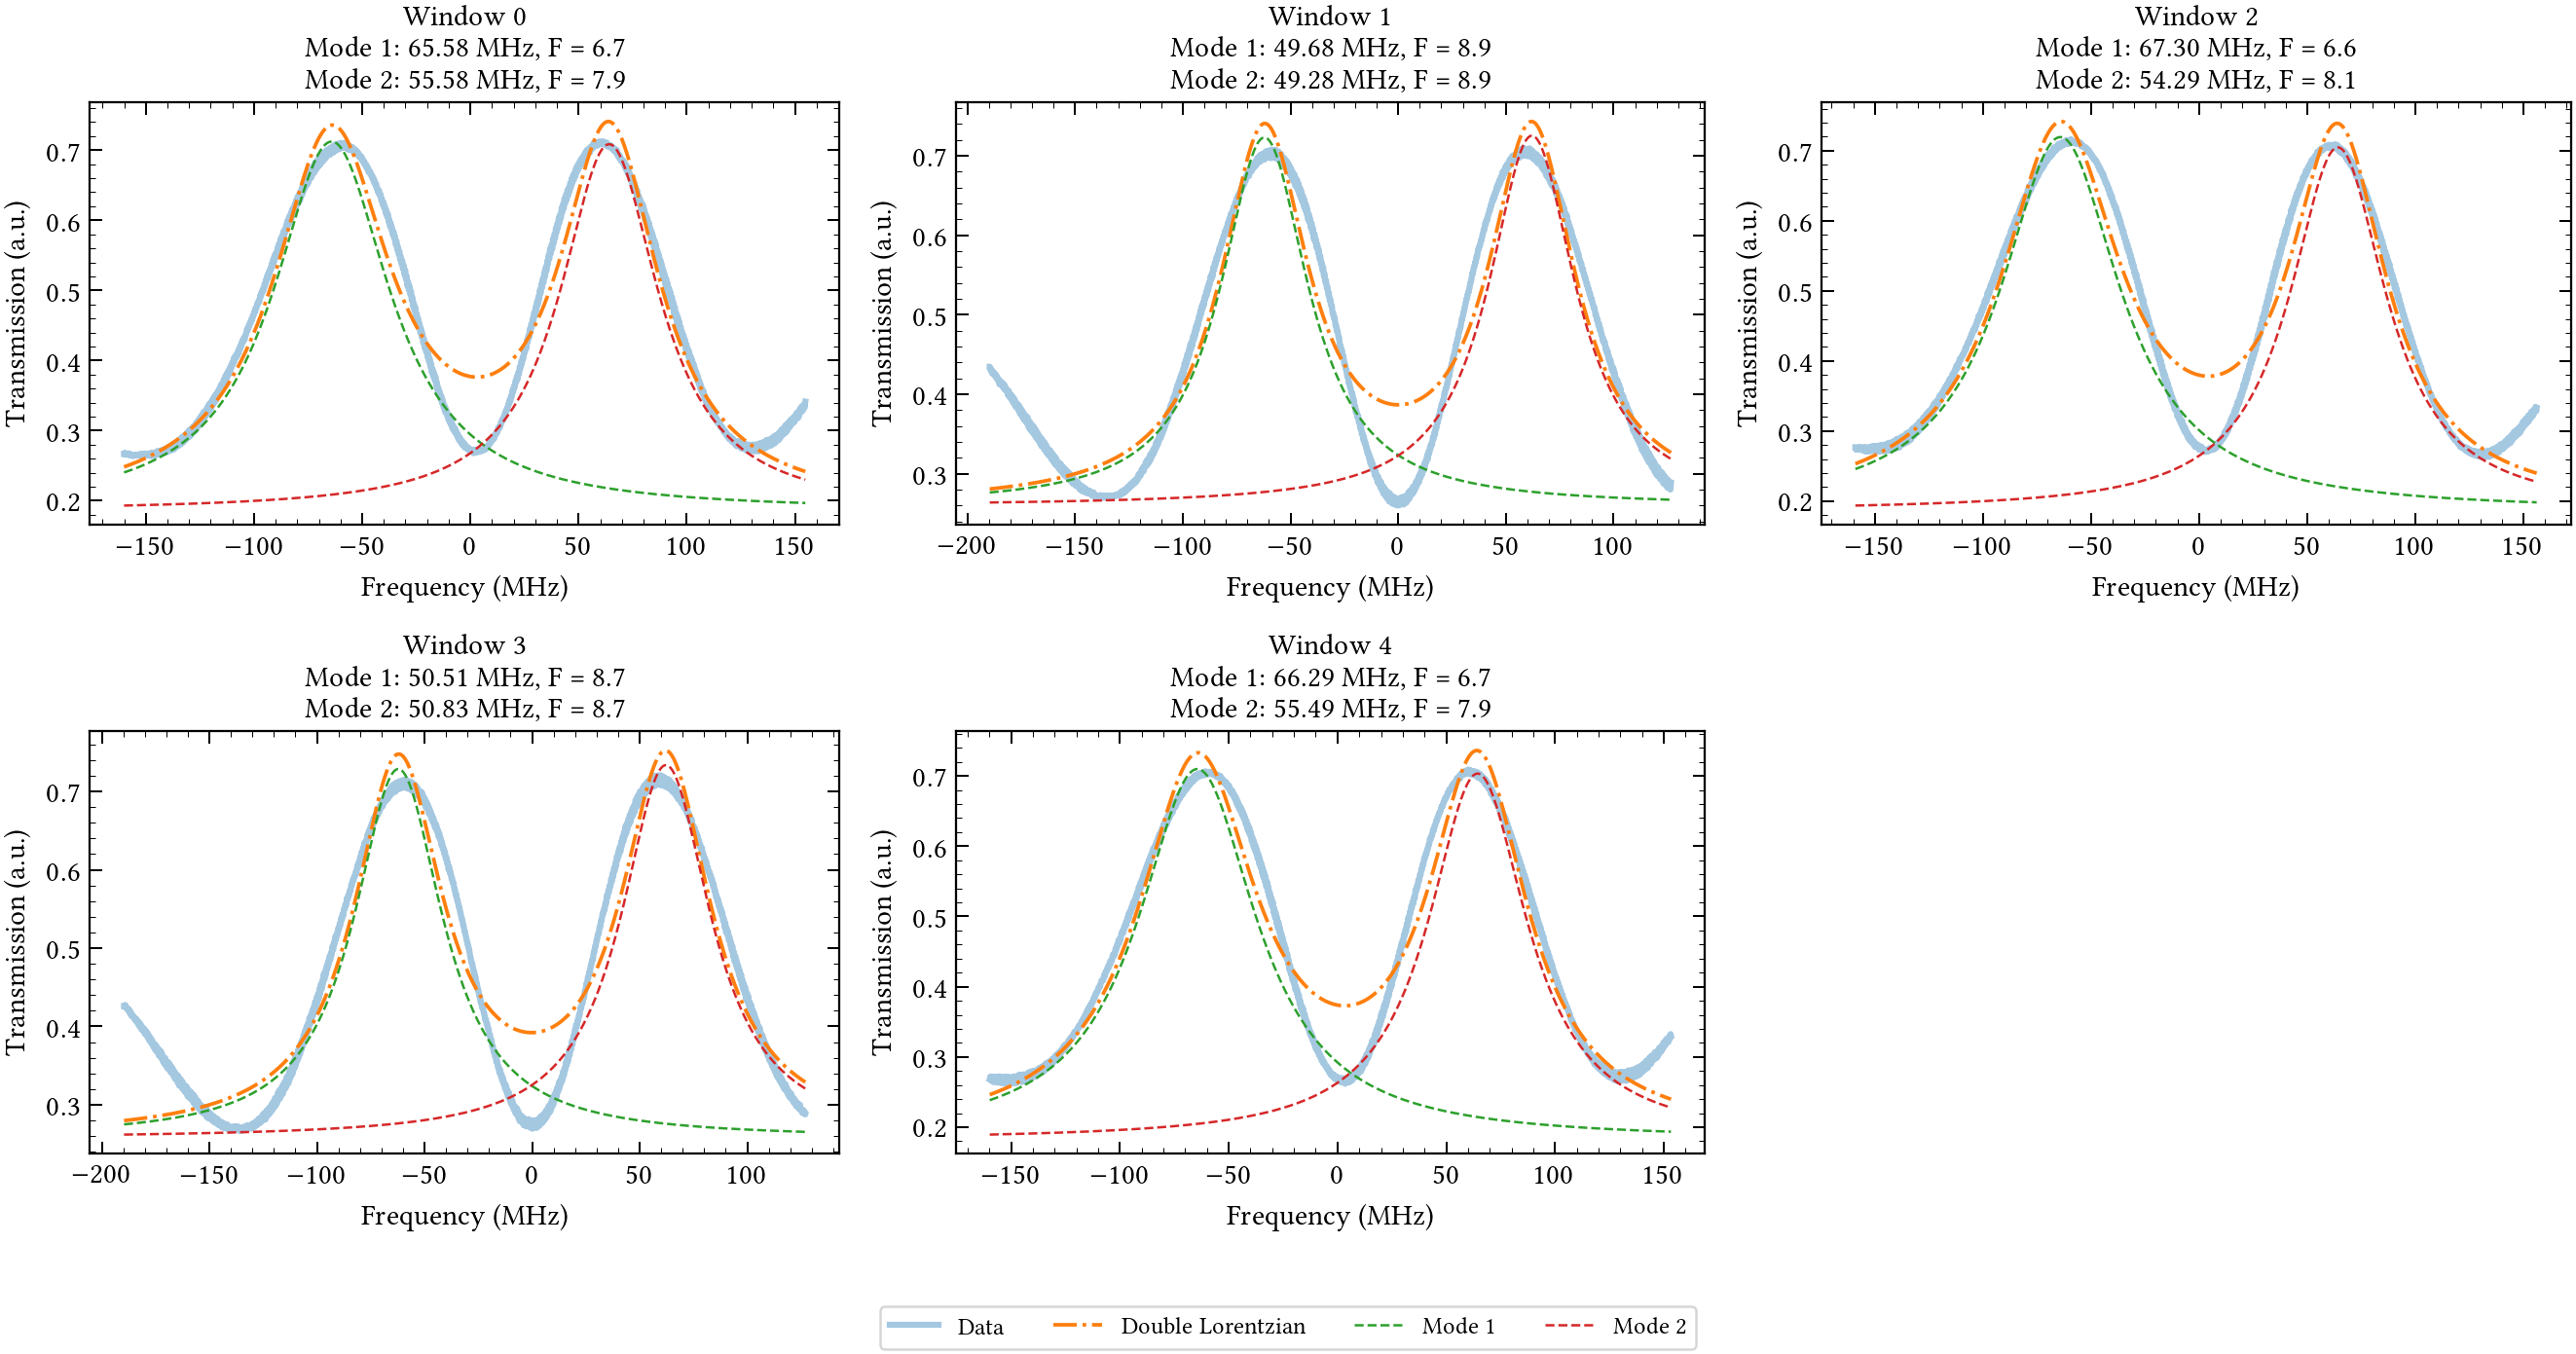

In [30]:
num_windows = len(double_peak_fits)

cols = 3
rows = int(np.ceil(num_windows / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(5 * cols, 4 * rows)
)

axes = np.array(axes).reshape(-1)

for i, fit in enumerate(double_peak_fits):

    ax = axes[i]

    xdata = fit["xdata"]
    ydata = fit["ydata"]

    A1 = fit["A1"]
    x01 = fit["x01"]
    gamma1 = fit["gamma1_time"]

    A2 = fit["A2"]
    x02 = fit["x02"]
    gamma2 = fit["gamma2_time"]

    C = fit["C"]

    t_fit = np.linspace(xdata[0], xdata[-1], 2000)

    component1 = lorentzian(t_fit, A1, x01, gamma1)
    component2 = lorentzian(t_fit, A2, x02, gamma2)

    total_fit = component1 + component2 + C

    # Reference frequency: middle of the two resonances
    x_reference = 0.5 * (x01 + x02)

    freq_data = (xdata - x_reference) * Hz_per_sec / 1e6
    freq_fit = (t_fit - x_reference) * Hz_per_sec / 1e6

    ax.plot(
        freq_data,
        ydata,
        alpha=0.4,
        lw=2.5,
        label="Data"
    )

    ax.plot(
        freq_fit,
        total_fit,
        "-.",
        lw=1.5,
        label="Double Lorentzian"
    )

    ax.plot(
        freq_fit,
        component1 + C,
        "--",
        lw=1,
        label="Mode 1"
    )

    ax.plot(
        freq_fit,
        component2 + C,
        "--",
        lw=1,
        label="Mode 2"
    )

    ax.set_title(
        f"Window {fit['window_id']}\n"
        f"Mode 1: {fit['gamma1_freq']/1e6:.2f} MHz, "
        f"F = {fit['finesse1']:.1f}\n"
        f"Mode 2: {fit['gamma2_freq']/1e6:.2f} MHz, "
        f"F = {fit['finesse2']:.1f}"
    )

    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Transmission (a.u.)")
    # ax.legend(fontsize=8)

# Remove empty axes
for j in range(num_windows, len(axes)):
    axes[j].axis("off")

# Get legend handles from the first subplot
handles, labels = axes[0].get_legend_handles_labels()

# Common legend below all plots
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)

# Leave room at the bottom for the legend
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

### Sinus fit

In [14]:
def sinus(x, A, f, phi, C):
    return A * np.sin(2 * np.pi * f * x + phi) + C

In [19]:
sinus_fits = []

for window_id, (start_idx, end_idx) in enumerate(segments):

    xdata = time[start_idx:end_idx]
    ydata = signal[start_idx:end_idx]

    # Center time around zero
    x_center = np.mean(xdata)
    xfit_data = xdata - x_center

    # Initial guesses
    C_guess = np.mean(ydata)
    A_guess = 0.5 * (np.max(ydata) - np.min(ydata))

    dt = np.median(np.diff(xfit_data))
    y_centered = ydata - C_guess

    # FFT estimate of frequency and phase
    fft_values = np.fft.rfft(y_centered)
    frequencies = np.fft.rfftfreq(len(y_centered), d=dt)
    spectrum = np.abs(fft_values)

    peak_index = np.argmax(spectrum[1:]) + 1

    f_guess = frequencies[peak_index]
    phi_guess = np.angle(fft_values[peak_index]) + np.pi / 2

    p0 = [
        A_guess,
        f_guess,
        phi_guess,
        C_guess
    ]

    popt, pcov = curve_fit(
        sinus,
        xfit_data,
        ydata,
        p0=p0,
        bounds=(
            [
                0,
                0.8 * f_guess,
                phi_guess - np.pi,
                np.min(ydata)
            ],
            [
                2 * A_guess,
                1.2 * f_guess,
                phi_guess + np.pi,
                np.max(ydata)
            ]
        ),
        maxfev=20000
    )

    sinus_fits.append({
        "window_id": window_id,
        "params": popt,
        "xdata": xdata,
        "ydata": ydata,
        "x_center": x_center
    })

print(f"Fitted {len(sinus_fits)} windows")

Fitted 5 windows


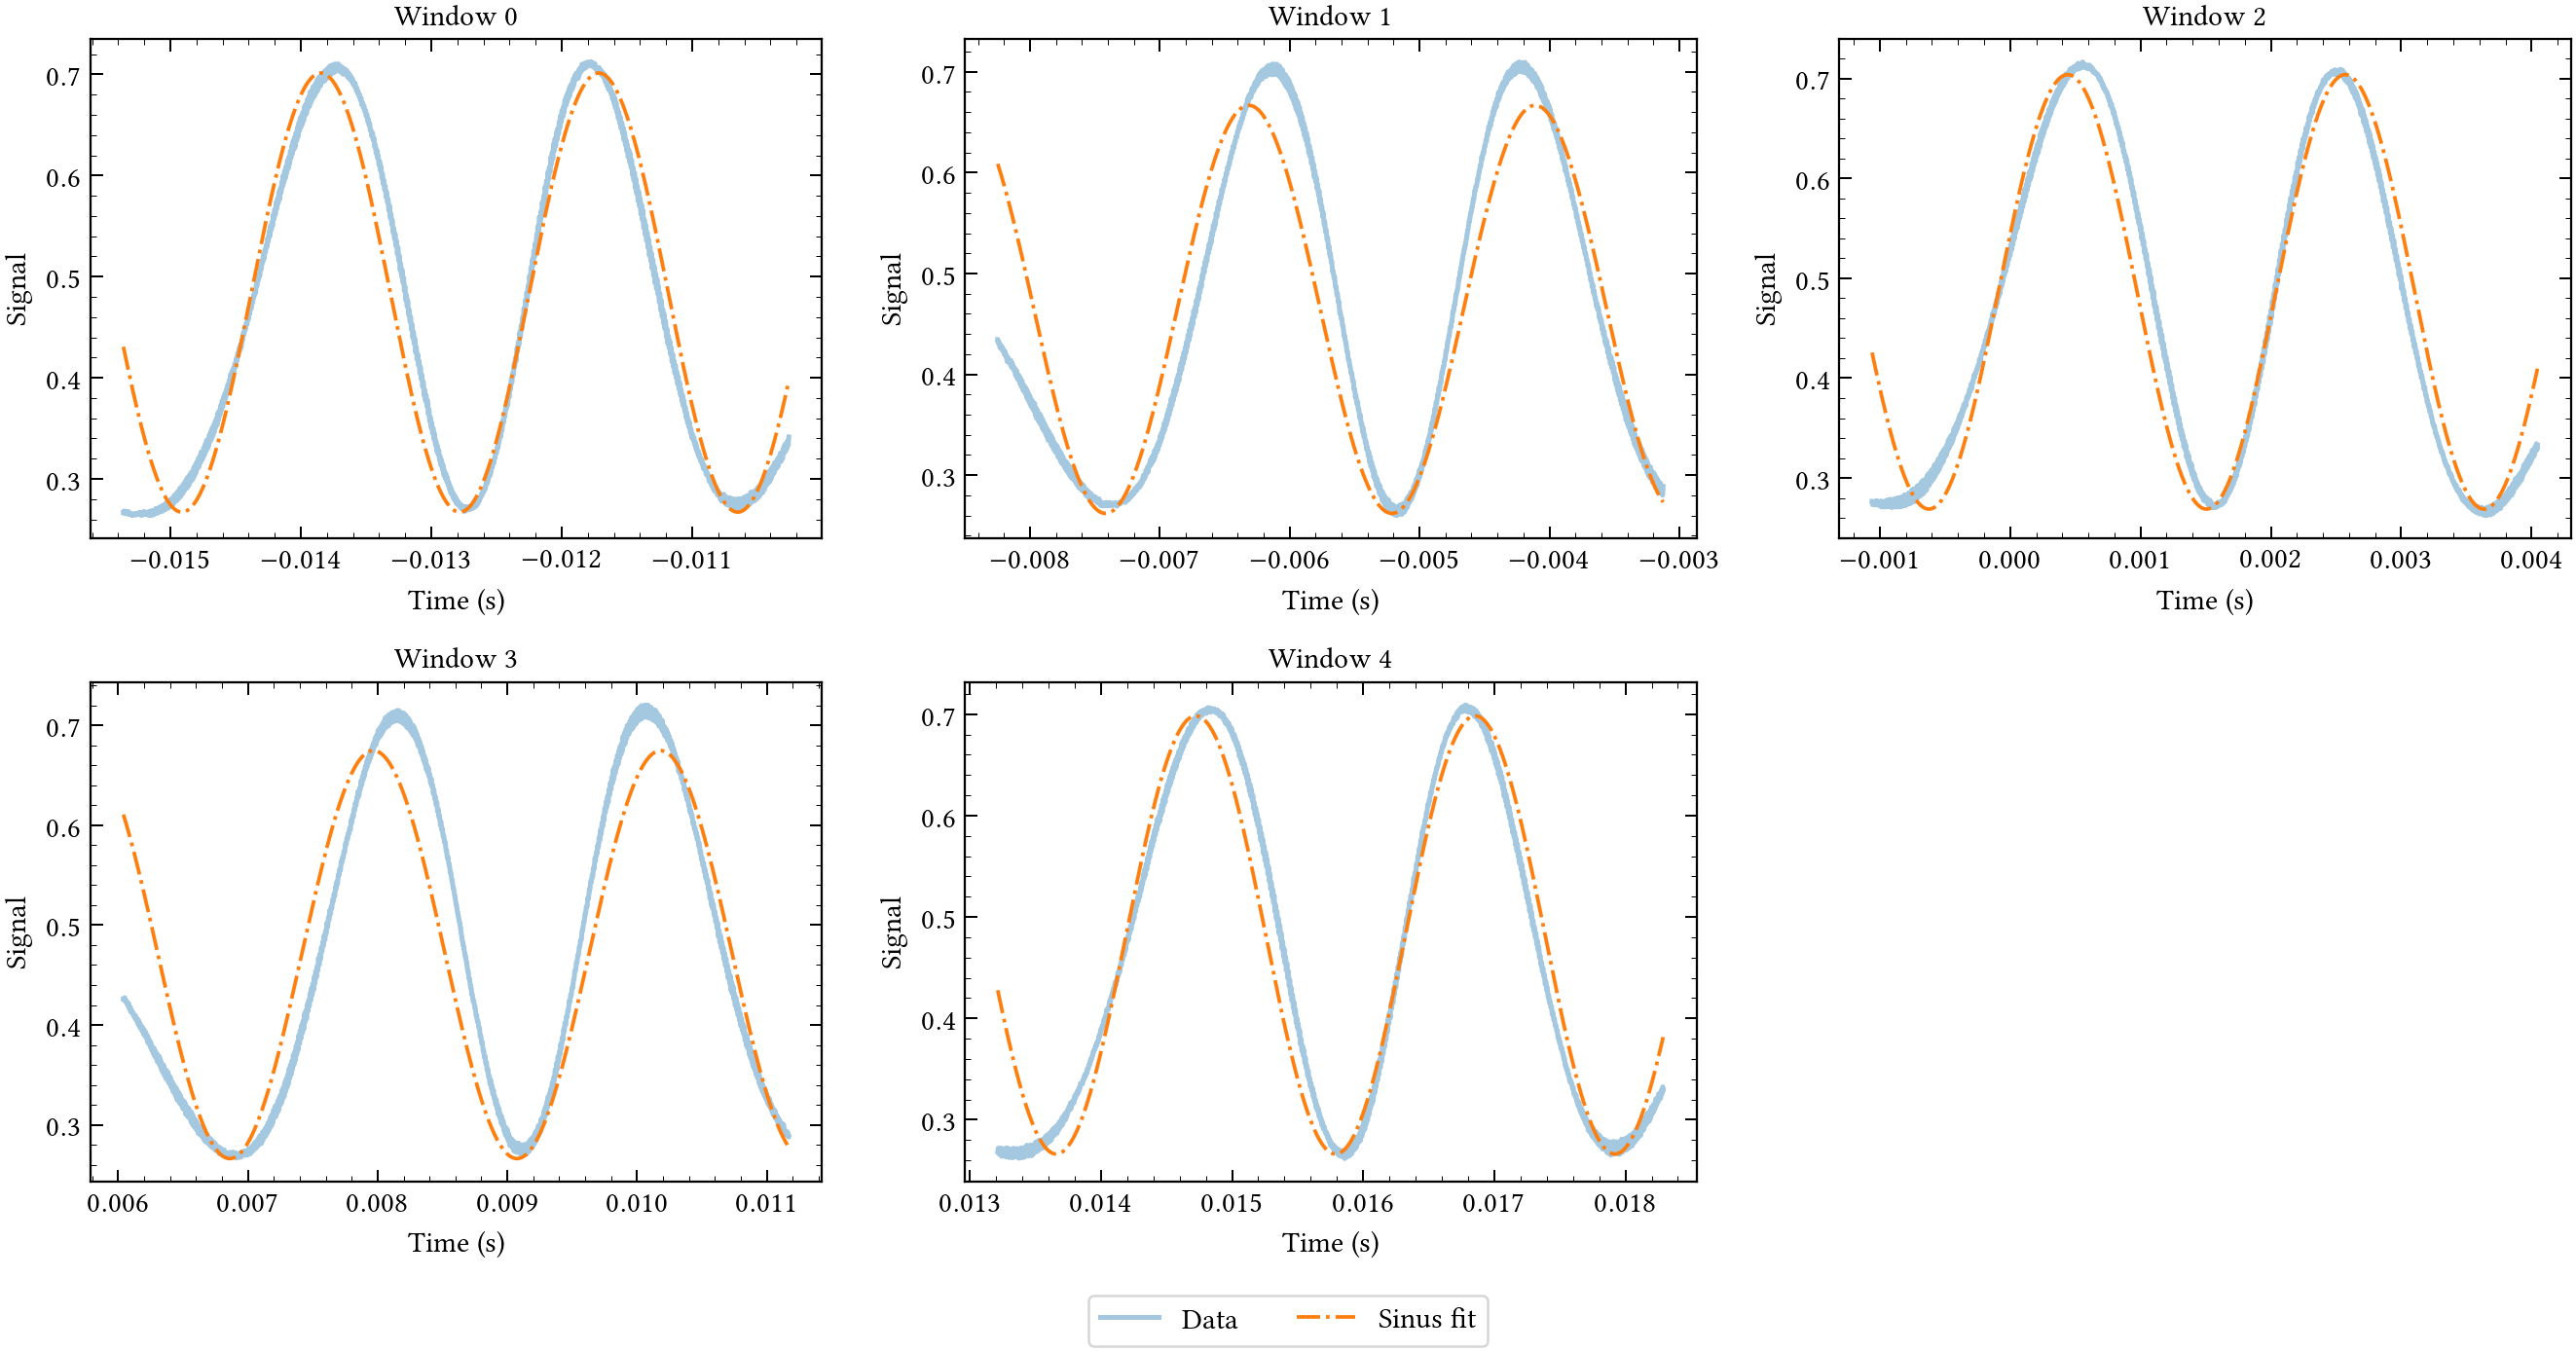

In [21]:
cols = 3
rows = int(np.ceil(len(sinus_fits) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = np.array(axes).reshape(-1)

for i, fit in enumerate(sinus_fits):

    ax = axes[i]

    x = fit["xdata"]
    y = fit["ydata"]

    A, f, phi, C = fit["params"]

    xfit = np.linspace(
        fit["xdata"][0],
        fit["xdata"][-1],
        2000
    )

    yfit = sinus(
        xfit - fit["x_center"],
        A,
        f,
        phi,
        C
    )

    ax.plot(x, y, lw=2, alpha=0.4, label="Data")
    ax.plot(xfit, yfit, "-.", lw=1.5, label="Sinus fit")

    ax.set_title(f"Window {fit['window_id']}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Signal")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

#### Airy

In [22]:
def airy(t, A, B, t0, Tfsr, Fc):
    phi = np.pi * (t - t0) / Tfsr
    return A / (1 + Fc * np.sin(phi)**2) + B

In [25]:
airy_fits = []

for window_id, (start_idx, end_idx) in enumerate(segments):

    xdata = time[start_idx:end_idx]
    ydata = signal[start_idx:end_idx]

    x_center = np.mean(xdata)
    xfit_data = xdata - x_center

    # --- Better peak-based initial guesses ---
    B_guess = np.min(ydata)
    I_max_guess = np.max(ydata)
    A_guess = I_max_guess - B_guess

    # Find actual peaks in the data to nail down t0 and Tfsr directly,
    # far more robust than FFT for a ~2-period window
    min_distance = max(int(len(ydata) / 6), 1)
    peak_idx, _ = find_peaks(ydata, distance=min_distance,
                              prominence=0.3 * A_guess)

    if len(peak_idx) >= 2:
        peak_times = xfit_data[peak_idx]
        Tfsr_guess = np.mean(np.diff(peak_times))
        t0_guess = peak_times[0]
    else:
        # fallback to FFT method if peak finding fails
        dt = np.median(np.diff(xfit_data))
        y_centered = ydata - np.mean(ydata)
        fft_values = np.fft.rfft(y_centered)
        frequencies = np.fft.rfftfreq(len(y_centered), d=dt)
        spectrum = np.abs(fft_values)
        peak_index = np.argmax(spectrum[1:]) + 1
        Tfsr_guess = 1.0 / frequencies[peak_index]
        t0_guess = xfit_data[np.argmax(ydata)]

    ratio_guess = I_max_guess / max(B_guess, 1e-6)
    Fc_guess = max(ratio_guess - 1, 0.5)

    p0 = [A_guess, B_guess, t0_guess, Tfsr_guess, Fc_guess]

    popt, pcov = curve_fit(
        airy,
        xfit_data,
        ydata,
        p0=p0,
        bounds=(
            [0.7 * A_guess, 0,           t0_guess - 0.1 * Tfsr_guess, 0.9 * Tfsr_guess, 0.05],
            [1.3 * A_guess, B_guess * 1.3, t0_guess + 0.1 * Tfsr_guess, 1.1 * Tfsr_guess, 50]
        ),
        loss="soft_l1",     # down-weights outliers / edge artifacts
        f_scale=0.02,       # residual scale where soft_l1 kicks in ﷿﷿﷿ tune to your noise level
        maxfev=20000
    )

    A, B, t0, Tfsr, Fc = popt
    finesse = np.pi / (2 * np.arcsin(1 / np.sqrt(Fc)))

    airy_fits.append({
        "window_id": window_id,
        "params": popt,
        "finesse": finesse,
        "xdata": xdata,
        "ydata": ydata,
        "x_center": x_center
    })

print(f"Fitted {len(airy_fits)} windows")
for f in airy_fits:
    print(f"Window {f['window_id']}: F = {f['finesse']:.2f}, Fc = {f['params'][4]:.2f}, "
          f"Tfsr = {f['params'][3]:.6f} s")

Fitted 5 windows
Window 0: F = 1.94, Fc = 1.91, Tfsr = 0.002101 s
Window 1: F = 1.92, Fc = 1.87, Tfsr = 0.002090 s
Window 2: F = 1.92, Fc = 1.88, Tfsr = 0.002166 s
Window 3: F = 1.92, Fc = 1.87, Tfsr = 0.002102 s
Window 4: F = 1.94, Fc = 1.91, Tfsr = 0.002154 s


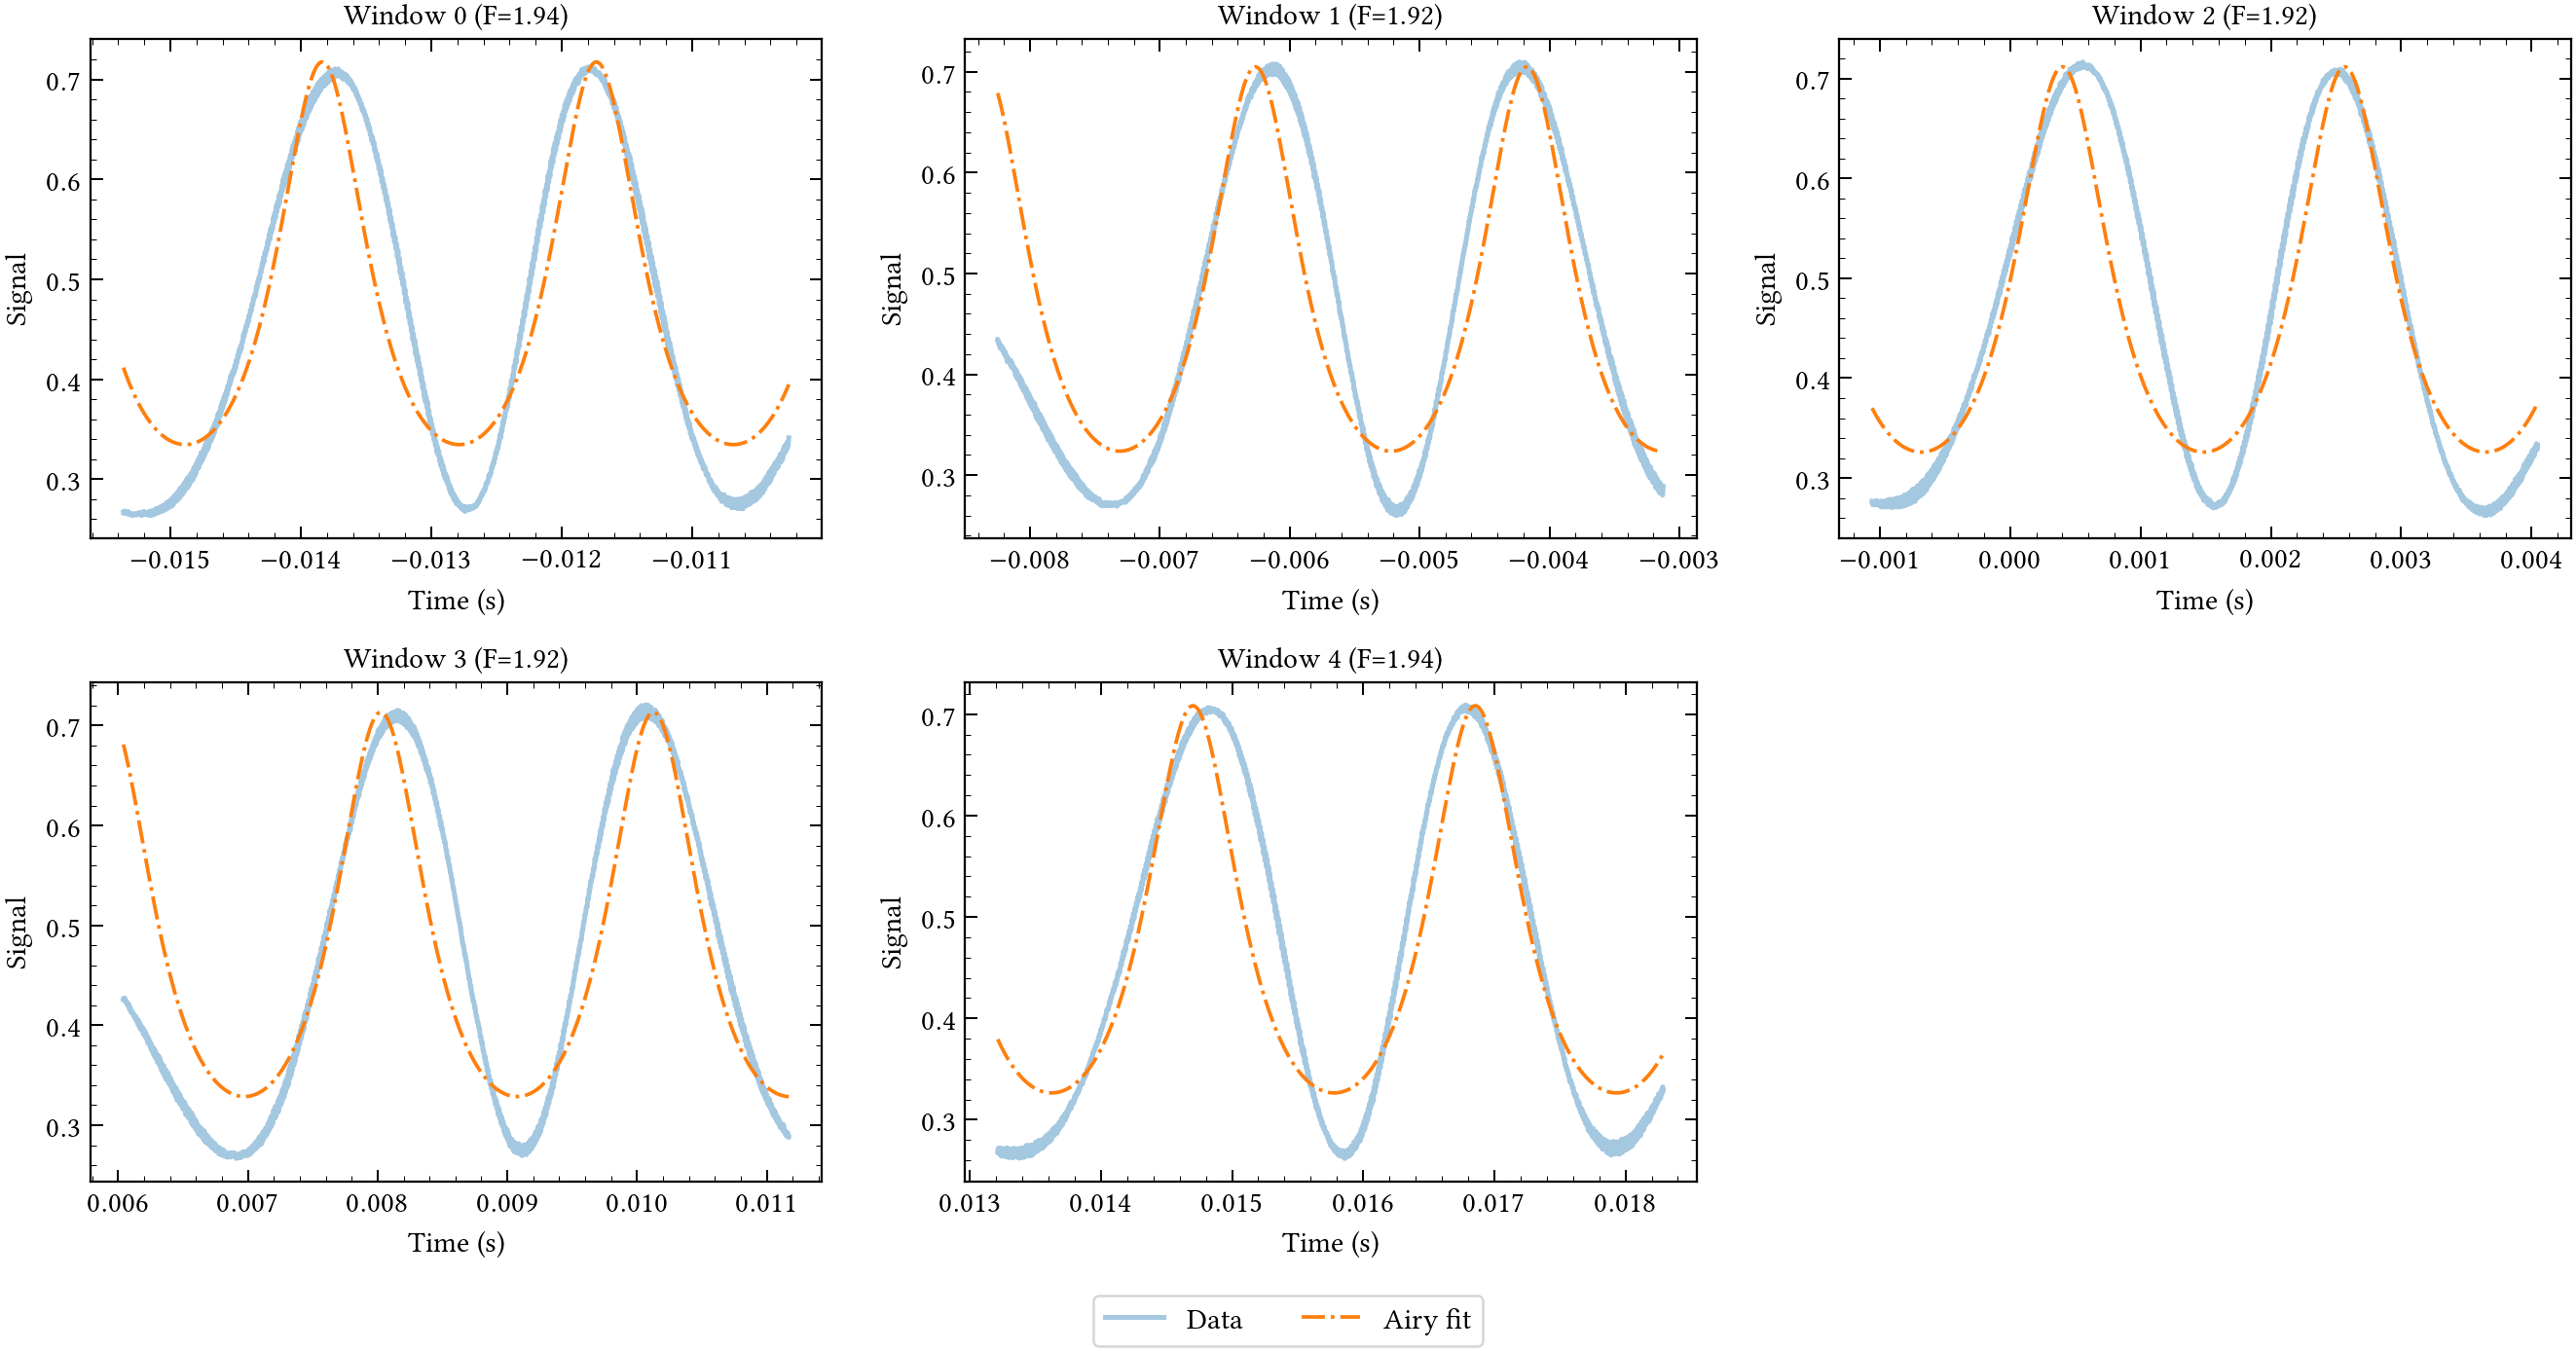

In [26]:
cols = 3
rows = int(np.ceil(len(airy_fits) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = np.array(axes).reshape(-1)

for i, fit in enumerate(airy_fits):

    ax = axes[i]

    x = fit["xdata"]
    y = fit["ydata"]

    A, B, t0, Tfsr, Fc = fit["params"]

    xfit = np.linspace(
        fit["xdata"][0],
        fit["xdata"][-1],
        2000
    )

    yfit = airy(
        xfit - fit["x_center"],
        A,
        B,
        t0,
        Tfsr,
        Fc
    )

    ax.plot(x, y, lw=2, alpha=0.4, label="Data")
    ax.plot(xfit, yfit, "-.", lw=1.5, label="Airy fit")

    ax.set_title(f"Window {fit['window_id']} (F={fit['finesse']:.2f})")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Signal")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()